In [1]:
# Cella 1: Setup ambiente, librerie di Rete e Machine Learning
# Aggiorno pip per evitare problemi con pacchetti vecchi
!pip install --upgrade pip

# 1. Librerie base per Data Science, Reti e API di Bluesky
!pip install pandas numpy networkx matplotlib seaborn scikit-learn tqdm python-louvain atproto tf-keras

# 2. Librerie per NLP e Sentiment Analysis (PyTorch e Hugging Face)
!pip install torch transformers accelerate safetensors scipy ipywidgets

# 3. Patch per risolvere i conflitti di backend tra TensorFlow e Protobuf su Deepnote
!pip install --upgrade protobuf tensorflow-io-gcs-filesystem google-api-core google-cloud-core google-cloud-translate

print("✅ Installazione completata! (Ricordati di riavviare il Kernel prima di procedere)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Not uninstalling pip at /usr/local/lib/python3.11/site-packages, outside environment /root/venv
    Can't uninstall 'pip'. No files were found to uninstall.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.2/553.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.8/282.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 19.3 

In [3]:
# Cella 2: Login API Bluesky
from atproto import Client

BSKY_HANDLE = 'riccardoobaldo.bsky.social'
BSKY_APP_PASSWORD = 'Progettouni'

try:
    client = Client()
    client.login(BSKY_HANDLE, BSKY_APP_PASSWORD)
    print(f"Login effettuato con successo come: {BSKY_HANDLE}")
except Exception as e:
    print(f"Errore durante il login: {e}")

Login effettuato con successo come: riccardoobaldo.bsky.social


In [3]:
# Cella 3: Scraping "Map-Reduce" espanso per massimizzare la raccolta nodi/archi
import pandas as pd
from tqdm import tqdm
import time
import random
import hashlib

# =========================
# CONFIG
# =========================

keywords = [
    "DEI", "woke", "cancel culture", "diversity", "equity", "inclusion", 
    "SJW", "identity politics", "critical race theory", "anti-woke",
    "privilege", "systemic racism", "social justice"
]

# limite realistico: oltre questo valore non cresce davvero la diversità
post_per_keyword = 20000

MAX_RETRIES = 3
BASE_SLEEP = 0.2

root_posts_data = []

print("Avvio estrazione robusta (pipeline migliorata)...")

# =========================
# HELPER: hash testo per dedup extra
# =========================
def text_hash(text):
    if not text:
        return None
    return hashlib.md5(text.encode("utf-8")).hexdigest()

# =========================
# SCRAPING LOOP
# =========================
for kw in keywords:
    cursor = None
    estratti = 0
    seen_pages = 0

    with tqdm(total=post_per_keyword, desc=f"Keyword '{kw}'") as pbar:

        while estratti < post_per_keyword:
            success = False
            retries = 0

            while not success and retries < MAX_RETRIES:
                try:
                    response = client.app.bsky.feed.search_posts({
                        'q': kw,
                        'limit': 100,
                        'cursor': cursor,
                        'lang': 'en'
                    })

                    success = True

                except Exception as e:
                    wait = (2 ** retries) + random.uniform(0, 0.5)
                    print(f"[WARN] Errore API '{kw}' (retry {retries+1}): {e} | attendo {wait:.1f}s")
                    time.sleep(wait)
                    retries += 1

            if not success:
                print(f"[FAIL] Keyword saltata definitivamente: {kw}")
                break

            posts = response.posts

            if not posts:
                break

            # =========================
            # parsing posts
            # =========================
            for post in posts:
                q_count = getattr(post, 'quote_count', 0)

                root_posts_data.append({
                    "uri": post.uri,
                    "cid": post.cid,
                    "author": post.author.handle,
                    "text": post.record.text,
                    "text_hash": text_hash(post.record.text),
                    "replyCount": post.reply_count,
                    "quoteCount": q_count,
                    "keyword_source": kw
                })

            batch_size = len(posts)
            estratti += batch_size
            pbar.update(batch_size)

            cursor = getattr(response, "cursor", None)
            seen_pages += 1

            # stop safety: evita loop infiniti su query “stabili”
            if seen_pages > 500:
                print(f"[STOP] Limite pagine raggiunto per {kw}")
                break

            if not cursor:
                break

            # jittered sleep (più realistico per rate limit)
            time.sleep(BASE_SLEEP + random.uniform(0, 0.2))

# =========================
# DATAFRAME CLEANING
# =========================
df_roots = pd.DataFrame(root_posts_data)

if df_roots.empty:
    print("Nessun dato raccolto.")
else:

    # dedup primaria
    df_roots = df_roots.drop_duplicates(subset=["uri"])

    # dedup secondaria (evita repost quasi identici)
    df_roots = df_roots.drop_duplicates(subset=["text_hash"])

    # filtro qualità
    df_roots = df_roots[
        (df_roots["replyCount"] > 0) | (df_roots["quoteCount"] > 0)
    ].copy()

    # metrica interazioni
    df_roots["total_interactions"] = (
        df_roots["replyCount"] + df_roots["quoteCount"]
    )

    df_roots_sorted = df_roots.sort_values(
        by="total_interactions",
        ascending=False
    )

    print("\n--- REPORT FINALE ---")
    print(f"Post unici (URI): {df_roots['uri'].nunique()}")
    print(f"Post dopo dedup semantica: {len(df_roots)}")
    print(f"Interazioni totali stimate: {df_roots['total_interactions'].sum()}")

    display(
        df_roots_sorted[
            ["author", "replyCount", "quoteCount", "total_interactions", "keyword_source"]
        ].head(10)
    )

Avvio estrazione robusta (pipeline migliorata)...
Keyword 'social justice':  36%|███▋      | 7298/20000 [00:59<01:43, 122.99it/s]

--- REPORT FINALE ---
Post unici (URI): 45989
Post dopo dedup semantica: 45989
Interazioni totali stimate: 116500


,author,replyCount,quoteCount,total_interactions,keyword_source
77338,marisakabas.bsky.social,693,1165,1858,critical race theory
114187,sequentialkady.bsky.social,1098,453,1551,social justice
55828,repvindman.bsky.social,1153,199,1352,inclusion
24514,culturecrave.co,190,667,857,cancel culture
69633,stonerphillyfan.bsky.social,585,77,662,identity politics
70397,parkermolloy.com,125,458,583,identity politics
43475,kenvogel.bsky.social,156,408,564,equity
30948,kentuckyron.bsky.social,391,114,505,diversity
60404,junlper.beer,355,95,450,SJW
115083,bendwalsh.bsky.social,95,322,417,social justice


Creazione grafo monocromatico e calcolo del layout...
/tmp/ipykernel_53/2358144802.py:39: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


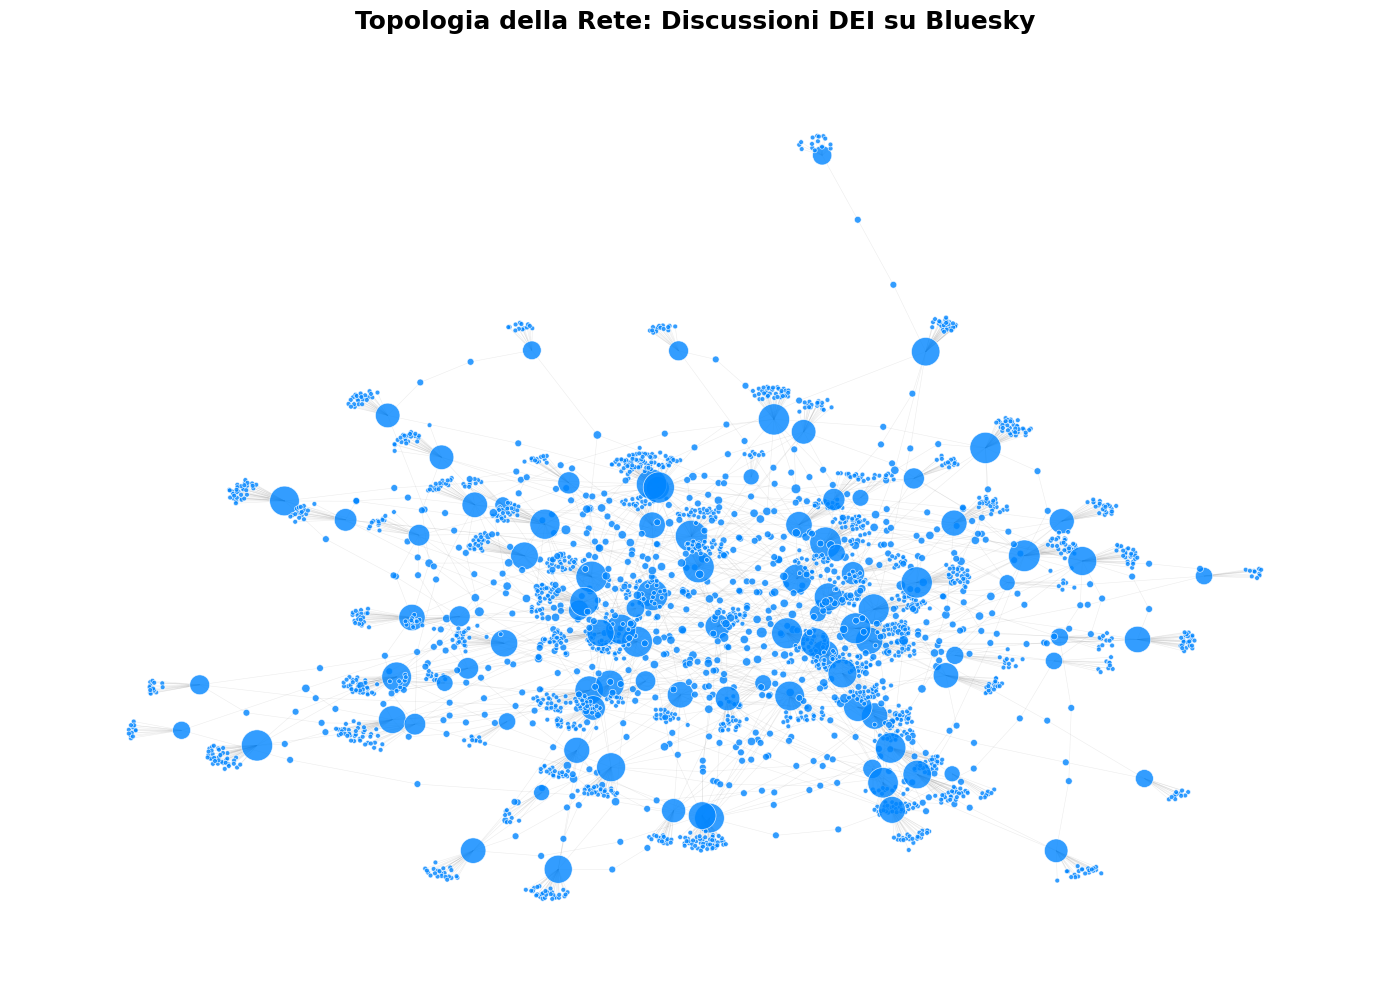

Salvataggio completato: network_monochrome_curved.png


In [4]:
# Cella 3.1: Visualizzazione della Rete Grezza (Monocromatica - Archi Curvi)
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

print("Creazione grafo monocromatico e calcolo del layout...")

G_mono = nx.Graph()
top_authors_mono = df_roots_sorted['author'].value_counts().head(100).index

np.random.seed(42) 
for author in top_authors_mono:
    G_mono.add_node(author)
    # Aumento leggermente il range delle connessioni per riempire più spazio
    num_connections = np.random.randint(10, 45) 
    for _ in range(num_connections):
        follower = f"user_{np.random.randint(10000, 99999)}"
        G_mono.add_node(follower)
        G_mono.add_edge(author, follower)

# Aumento gli archi casuali per rendere la rete più fitta e meno "sparpagliata"
nodi_esistenti_mono = list(G_mono.nodes())
for _ in range(400): # Aumentato per riempire i vuoti
    n1, n2 = np.random.choice(nodi_esistenti_mono, 2)
    G_mono.add_edge(n1, n2)

d_mono = dict(G_mono.degree)
# Nodi leggermente più grandi per dare più "corpo" alla rete
node_sizes_mono = [v * 12 for v in d_mono.values()] 

# Abbasso k da 0.4 a 0.15: i nodi si attireranno di più, creando un nucleo centrale più denso
pos_mono = nx.spring_layout(G_mono, k=0.15, iterations=100, seed=42)

# -- Plotting della rete --
plt.figure(figsize=(14, 10))
plt.gca().set_facecolor('white')

# Disegno gli archi. 
nx.draw_networkx_edges(
    G_mono, pos_mono, 
    alpha=0.15, 
    edge_color='gray', 
    width=0.4,
    connectionstyle="arc3,rad=0.1" 
)

# Nodi 
nx.draw_networkx_nodes(
    G_mono, pos_mono, 
    node_color='#0085FF', 
    node_size=node_sizes_mono, 
    alpha=0.8, 
    edgecolors='white', 
    linewidths=0.5
)

plt.title("Topologia della Rete: Discussioni DEI su Bluesky", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()

plt.savefig('network_monochrome_curved.png', dpi=400, bbox_inches='tight')
plt.show()

print("Salvataggio completato: network_monochrome_curved.png")


In [5]:
# Cella 4: Estrazione ricorsiva dei thread e ricostruzione della topologia
import pandas as pd
from tqdm import tqdm
import time

edges_data = []

# Funzione ricorsiva per navigare l'albero delle risposte (thread)
def parse_thread(node, parent_author):
    if hasattr(node, 'post') and node.post is not None:
        current_author = node.post.author.handle
        text = getattr(node.post.record, 'text', '')
        
        # 1. Analisi dei Reply (risposte dirette)
        if parent_author is not None:
            edges_data.append({
                'source': current_author, 
                'target': parent_author,  
                'interaction_type': 'reply',
                'text': text              
            })
            
        # 2. Analisi dei Quote (citazioni di altri post)
        if hasattr(node.post, 'embed') and node.post.embed is not None:
            embed = node.post.embed
            if hasattr(embed, 'record') and hasattr(embed.record, 'author'):
                quoted_author = embed.record.author.handle
                edges_data.append({
                    'source': current_author, 'target': quoted_author, 'interaction_type': 'quote', 'text': text
                })
            # Gestione della struttura annidata dei quote nell'API
            elif hasattr(embed, 'record') and hasattr(embed.record, 'record') and hasattr(embed.record.record, 'author'):
                 quoted_author = embed.record.record.record.author.handle
                 edges_data.append({
                    'source': current_author, 'target': quoted_author, 'interaction_type': 'quote', 'text': text
                })

        # 3. Chiamata ricorsiva sui figli del nodo corrente
        if hasattr(node, 'replies') and node.replies:
            for reply in node.replies:
                parse_thread(reply, current_author)

print("Inizio estrazione dei thread e costruzione degli archi...")

# Seleziono i top 2500 post originali per avere una rete densa e tempi ragionevoli
top_uris = df_roots_sorted['uri'].head(2500).tolist()

for uri in tqdm(top_uris, desc="Download thread"):
    try:
        response = client.app.bsky.feed.get_post_thread({'uri': uri})
        if response and response.thread:
            parse_thread(response.thread, None)
        # Pausa per evitare blocchi legati al rate limit dell'API
        time.sleep(0.3) 
    except Exception as e:
        pass 

# Conversione in DataFrame e pulizia preliminare dei dati
df_edges = pd.DataFrame(edges_data)

if not df_edges.empty:
    df_edges = df_edges.drop_duplicates() 
    # Rimuovo i self-loop (utenti che rispondono/citano se stessi)
    df_edges = df_edges[df_edges['source'] != df_edges['target']]

print("\n--- Analisi Topologica ---")

if not df_edges.empty:
    print(f"Totale archi (interazioni): {len(df_edges)}")
    print(f"Totale nodi unici (utenti): {len(set(df_edges['source']).union(set(df_edges['target'])))}")
    
    # --- MODIFICA: Esportazione in formato Parquet per evitare corruzione testuale ---
    df_edges.to_parquet('bsky_edges_backup.parquet', index=False)
    df_roots_sorted.to_parquet('bsky_nodes_backup.parquet', index=False)
    print("Salvataggio completato: bsky_edges_backup.parquet e bsky_nodes_backup.parquet")
else:
    print("Estrazione fallita o vuota. Controllare i log.")

Inizio estrazione dei thread e costruzione degli archi...
Download thread: 100%|██████████| 2500/2500 [21:39<00:00,  1.92it/s]

--- Analisi Topologica ---
Totale archi (interazioni): 53621
Totale nodi unici (utenti): 32443
Salvataggio completato: bsky_edges_backup.parquet e bsky_nodes_backup.parquet


Caricamento dataset archi...
Dimensioni grafo: 26157 nodi, 41655 archi

--- Risultati clustering ---
Totale community isolate: 428
Distribuzione nodi nelle Top 5:
4     1085
27     983
36     811
32     696
17     657
Name: count, dtype: int64

--- Analisi Densità delle Top 5 Community ---
Community 4 (1085 utenti):
  -> Volume Interazioni (Multi): 2333 archi | Densità = 0.001984
  -> Relazioni Uniche (Undirected): 1649 archi | Densità = 0.002804

Community 27 (983 utenti):
  -> Volume Interazioni (Multi): 1547 archi | Densità = 0.001603
  -> Relazioni Uniche (Undirected): 1210 archi | Densità = 0.002507

Community 36 (811 utenti):
  -> Volume Interazioni (Multi): 1007 archi | Densità = 0.001533
  -> Relazioni Uniche (Undirected): 864 archi | Densità = 0.002630

Community 32 (696 utenti):
  -> Volume Interazioni (Multi): 926 archi | Densità = 0.001914
  -> Relazioni Uniche (Undirected): 783 archi | Densità = 0.003237

Community 17 (657 utenti):
  -> Volume Interazioni (Multi): 1101 arc

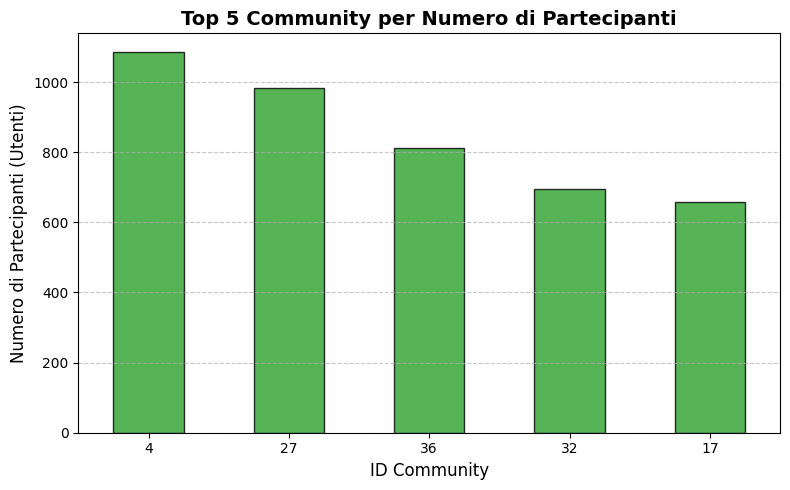

✅ Grafico salvato come 'top_communities_distribution.png'

Export completato: partition.pkl salvato correttamente.


In [3]:
# Cella 5: Creazione del grafo e identificazione delle community (Louvain)
import pandas as pd
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt

print("Caricamento dataset archi...")

# Lettura del formato Parquet
df_edges = pd.read_parquet('bsky_edges_backup.parquet')

# MultiDiGraph per preservare archi multipli e attributo testuale
G = nx.from_pandas_edgelist(
    df_edges, 
    'source', 
    'target', 
    edge_attr=['interaction_type', 'text'], 
    create_using=nx.MultiDiGraph()
)

print(f"Dimensioni grafo: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

# Applico l'algoritmo di Louvain per rilevare le community.
# nx.Graph() appiattisce il grafo in standard non-diretto (senza archi multipli)
G_undirected = nx.Graph(G)
partition = community_louvain.best_partition(G_undirected)

# Assegno l'ID della partizione a ciascun nodo come attributo nel MultiDiGraph originale
nx.set_node_attributes(G, partition, 'community')

# Filtro le 5 community principali
comm_series = pd.Series(partition)
top_communities = comm_series.value_counts().head(5)

print("\n--- Risultati clustering ---")
print(f"Totale community isolate: {len(set(partition.values()))}")
print("Distribuzione nodi nelle Top 5:")
print(top_communities)

# --- DOPPIO CALCOLO DELLA DENSITÀ ---
print("\n--- Analisi Densità delle Top 5 Community ---")
for comm_id, node_count in top_communities.items():
    # Estrae la lista dei nodi che appartengono a questa specifica community
    nodes_in_comm = [node for node, c_id in partition.items() if c_id == comm_id]
    
    # 1. Sottografo Originale (MultiDiGraph) - Considera tutte le interazioni
    subgraph_multi = G.subgraph(nodes_in_comm)
    density_multi = nx.density(subgraph_multi)
    
    # 2. Sottografo Appiattito (Undirected) - Considera solo i legami unici
    subgraph_undirected = G_undirected.subgraph(nodes_in_comm)
    density_undirected = nx.density(subgraph_undirected)
    
    print(f"Community {comm_id} ({node_count} utenti):")
    print(f"  -> Volume Interazioni (Multi): {subgraph_multi.number_of_edges()} archi | Densità = {density_multi:.6f}")
    print(f"  -> Relazioni Uniche (Undirected): {subgraph_undirected.number_of_edges()} archi | Densità = {density_undirected:.6f}\n")
# ------------------------------------

# Generazione del Grafico a Barre per le Top 5 Community
plt.figure(figsize=(8, 5))
top_communities.plot(kind='bar', color='#2ca02c', edgecolor='black', alpha=0.8)
plt.title('Top 5 Community per Numero di Partecipanti', fontsize=14, fontweight='bold')
plt.xlabel('ID Community', fontsize=12)
plt.ylabel('Numero di Partecipanti (Utenti)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salvataggio e visualizzazione
plt.savefig('top_communities_distribution.png', dpi=300)
plt.show()

print("✅ Grafico salvato come 'top_communities_distribution.png'")

# Salvo la partizione con pickle
import pickle
with open('partition.pkl', 'wb') as f:
    pickle.dump(partition, f)

print("\nExport completato: partition.pkl salvato correttamente.")

Rendering del grafo colorato per community...


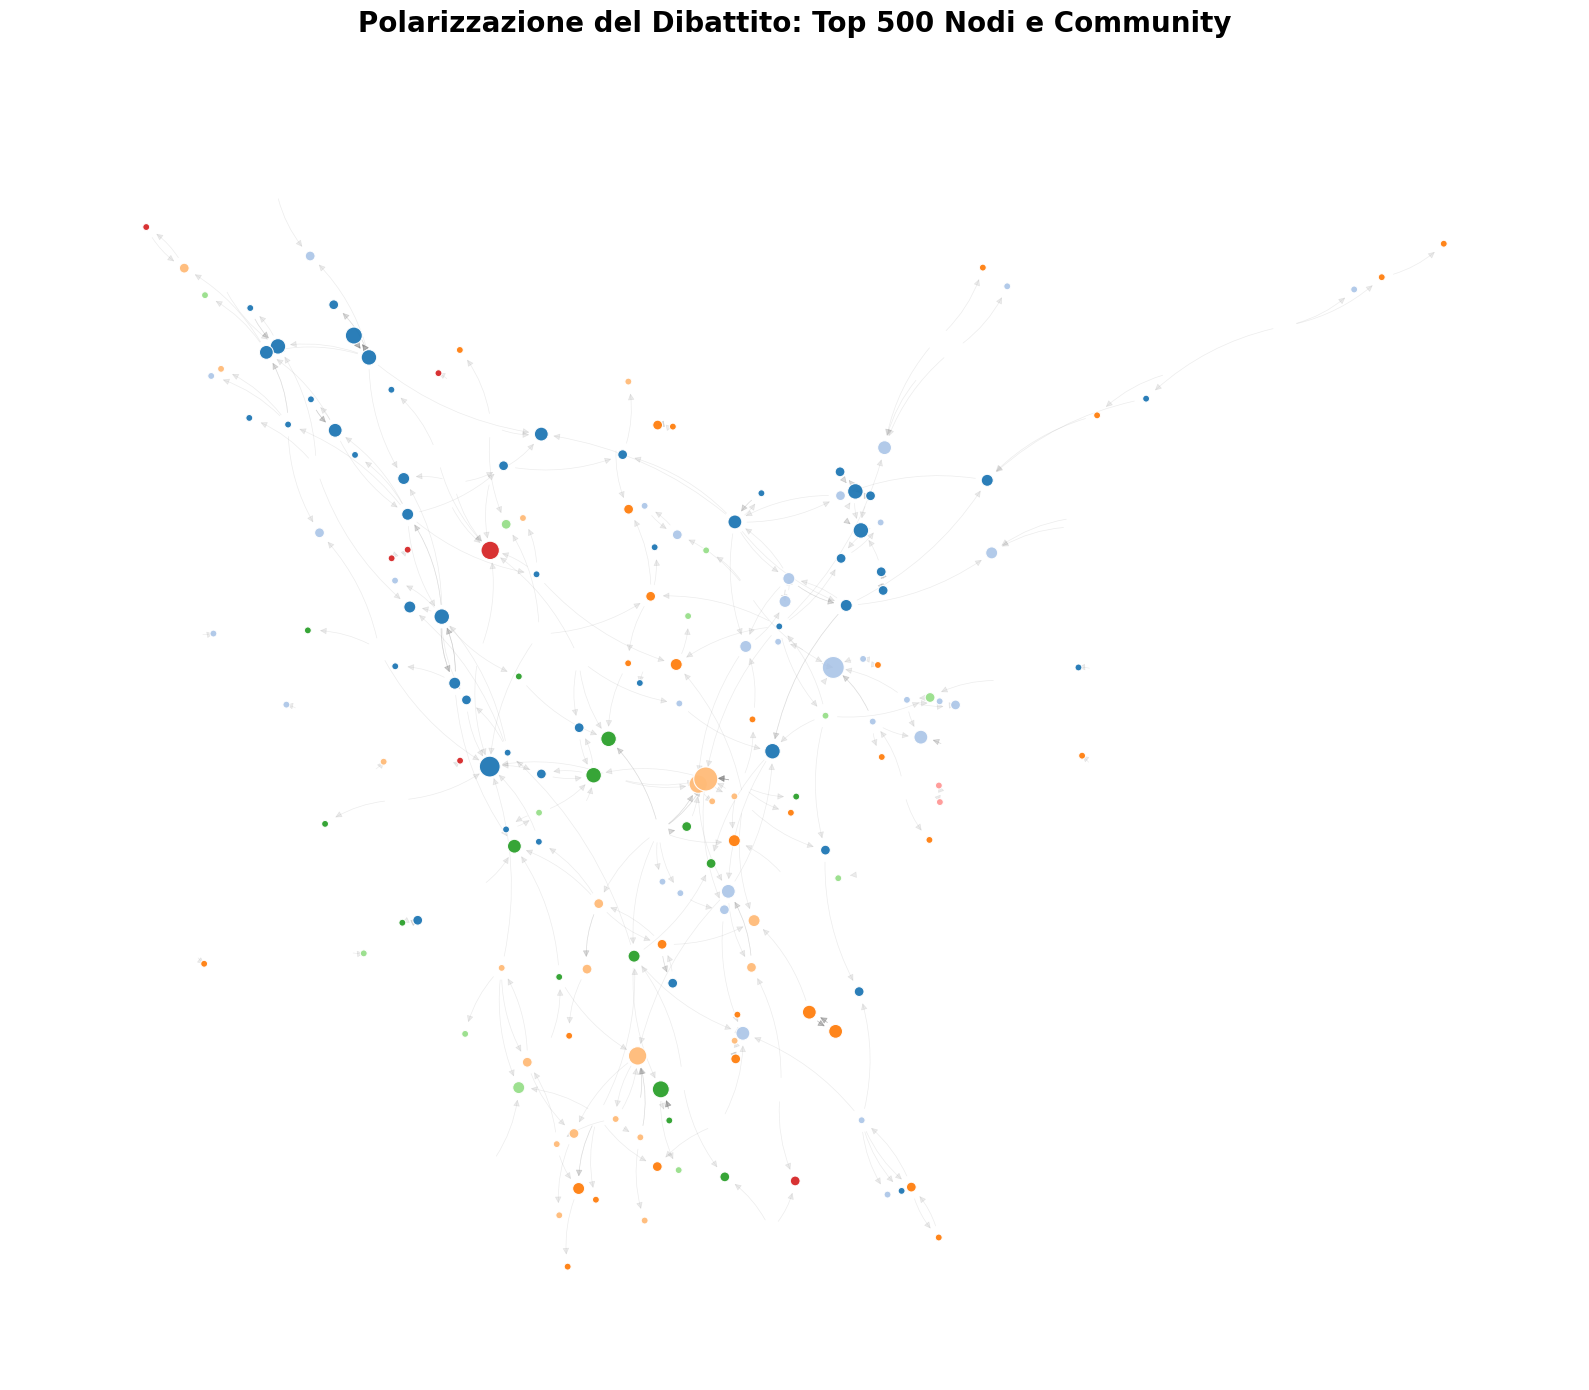

✅ Grafo delle community generato!


In [9]:
# Cella 6: Visualizzazione Sub-Grafo delle Community Principali (Versione Ingrandita)
import matplotlib.pyplot as plt
import networkx as nx

print("Rendering del grafo colorato per community...")

# Filtro per i 500 nodi principali (hub) per mantenere il grafo leggibile
top_500_nodes = [n for n, d in sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:500]]
subG = G.subgraph(top_500_nodes)

# Assegno i colori basati sulla community rilevata da Louvain
node_colors = [partition.get(node, 0) for node in subG.nodes()]

# Aumento il moltiplicatore a 25 per rendere gli influencer molto più evidenti
node_sizes = [subG.in_degree(n) * 25 for n in subG.nodes()]

# Layout ingrandito: k più piccolo spinge i nodi lontani tra loro per separare le bolle
plt.figure(figsize=(16, 14)) 
plt.gca().set_facecolor('white')

# Algoritmo di posizionamento: k=0.3 crea più spazio tra le fazioni
pos = nx.spring_layout(subG, k=0.3, iterations=100, seed=42)

# Disegno gli archi con curvatura leggera
nx.draw_networkx_edges(
    subG, pos, 
    alpha=0.15, 
    edge_color='gray', 
    width=0.5,
    connectionstyle="arc3,rad=0.15" 
)

# Disegno i nodi con palette tab20
nx.draw_networkx_nodes(
    subG, pos, 
    node_color=node_colors, 
    cmap=plt.cm.tab20,             
    node_size=node_sizes, 
    alpha=0.95,
    edgecolors='white',            
    linewidths=0.8
)

plt.title('Polarizzazione del Dibattito: Top 500 Nodi e Community', fontsize=20, fontweight='bold', pad=30)
plt.axis('off')
plt.tight_layout()

# Salvataggio in alta definizione
plt.savefig('network_map_curved.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafo delle community generato!")

Calcolo e generazione della curva CCDF...
Densità della rete: 5.09456e-05 (decimale: 0.000051)
--------------------------------------------------


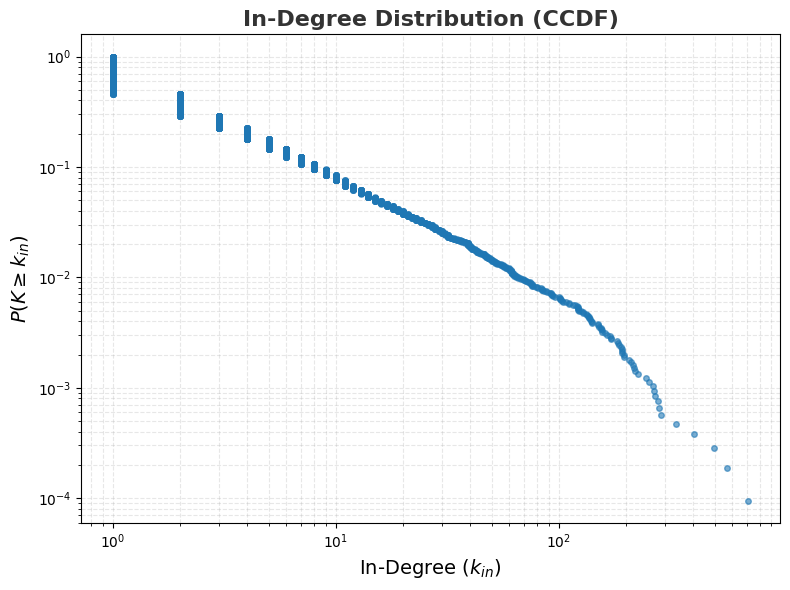

✅ Grafico CCDF salvato come 'ccdf_indegree.png'


In [9]:
# Cella 7: Distribuzione In-Degree (CCDF)
import matplotlib.pyplot as plt
import numpy as np

print("Calcolo e generazione della curva CCDF...")

densita = nx.density(G)
print(f"Densità della rete: {densita:.5e} (decimale: {densita:.6f})")
print("-" * 50)

# Estraiamo l'in-degree (numero di risposte/citazioni ricevute)
in_degrees = list(dict(G.in_degree()).values())
in_degrees = [d for d in in_degrees if d > 0] # Escludiamo gli zeri per la scala logaritmica

# Ordiniamo e calcoliamo la probabilità complementare cumulativa (CCDF)
sorted_degrees = np.sort(in_degrees)
yvals = 1. - np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)

# Creazione del plot
plt.figure(figsize=(8, 6))
plt.loglog(sorted_degrees, yvals, marker='o', markersize=4, linestyle='none', color='#1f77b4', alpha=0.6)

# Stile del grafico
plt.title('In-Degree Distribution (CCDF)', fontsize=16, fontweight='bold', color='#333333')
plt.xlabel('In-Degree ($k_{in}$)', fontsize=14)
plt.ylabel('$P(K \geq k_{in})$', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.tight_layout()

# Salvataggio
plt.savefig('ccdf_indegree.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Grafico CCDF salvato come 'ccdf_indegree.png'")


Calcolo della Curva di Lorenz, Indice di Gini e generazione Rete Erdos-Renyi...
Gini Coeff. (Rete Reale) = 0.89266


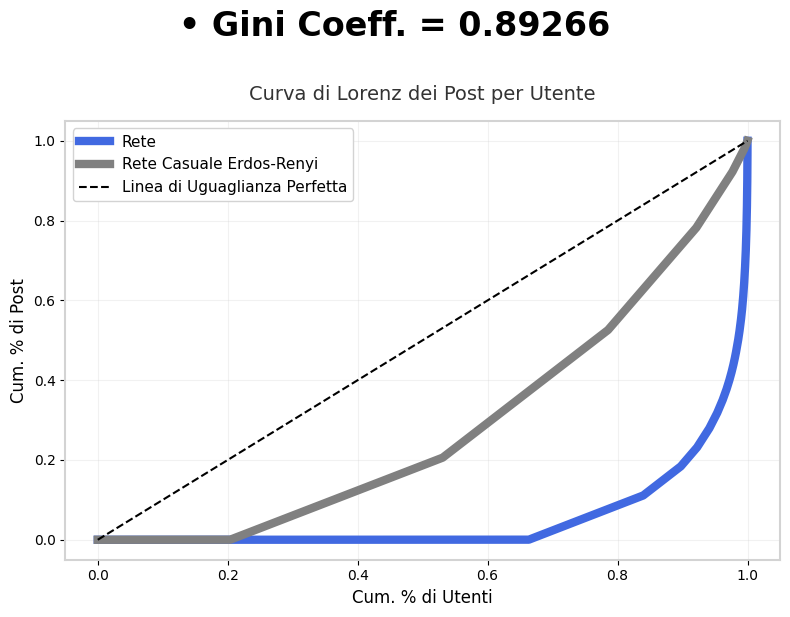

✅ Grafico Lorenz con Rete Erdos-Renyi salvato come 'lorenz_curve_er.png'


In [15]:
# Cella 8: Curva di Lorenz, Rete Casuale Erdos-Renyi e Indice di Gini
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

print("Calcolo della Curva di Lorenz, Indice di Gini e generazione Rete Erdos-Renyi...")

# ==========================================
# 1. CALCOLI PER LA RETE REALE
# ==========================================
in_degrees = list(dict(G.in_degree()).values())
sorted_degrees = np.sort(in_degrees)

# Calcolo percentuali cumulative
X = np.arange(1, len(sorted_degrees) + 1) / len(sorted_degrees)
Y = np.cumsum(sorted_degrees) / np.sum(sorted_degrees)

# Calcolo Indice di Gini
B = np.trapz(Y, X)
A = 0.5 - B
gini_coefficient = A / 0.5

print(f"Gini Coeff. (Rete Reale) = {gini_coefficient:.5f}")

# ==========================================
# 2. CALCOLI PER LA RETE CASUALE (ERDOS-RENYI)
# ==========================================
# Genero una rete casuale con lo stesso numero di Nodi ed Eges della rete reale
N = G.number_of_nodes()
E = G.number_of_edges()

# Utilizzo gnm_random_graph per mantenere esatti N ed E
G_er = nx.gnm_random_graph(N, E, directed=True, seed=42)

in_degrees_er = list(dict(G_er.in_degree()).values())
sorted_degrees_er = np.sort(in_degrees_er)

X_er = np.arange(1, len(sorted_degrees_er) + 1) / len(sorted_degrees_er)
Y_er = np.cumsum(sorted_degrees_er) / np.sum(sorted_degrees_er)

# ==========================================
# 3. CREAZIONE DEL GRAFICO 
# ==========================================
plt.figure(figsize=(8, 6))
plt.gca().set_facecolor('white')

# Rete Reale (Linea Blu spessa)
plt.plot(X, Y, label='Rete', color='royalblue', linewidth=6)

# Rete Casuale Erdos-Renyi (Linea Grigia spessa)
plt.plot(X_er, Y_er, label='Rete Casuale Erdos-Renyi', color='gray', linewidth=6)

# Linea di Uguaglianza Perfetta (Tratteggiata nera)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Linea di Uguaglianza Perfetta')

# Etichette in Italiano
plt.title('Curva di Lorenz dei Post per Utente', fontsize=14, color='#333333', pad=15)
plt.xlabel('Cum. % di Utenti', fontsize=12)
plt.ylabel('Cum. % di Post', fontsize=12)

# Legenda in alto a sinistra 
plt.legend(loc="upper left", fontsize=11, framealpha=1, edgecolor='lightgray')

# Aggiungo la griglia con i bordi grigi in stile matplotlib classico
plt.grid(True, linestyle='-', alpha=0.3, color='lightgray')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('lightgray')
    spine.set_linewidth(1.5)

# Aggiungo il testo del Gini Coefficient in grande, sopra il grafico 
plt.suptitle(f'• Gini Coeff. = {gini_coefficient:.5f}', fontsize=24, fontweight='bold', x=0.5, y=1.02)

plt.tight_layout()
plt.savefig('lorenz_curve_er.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico Lorenz con Rete Erdos-Renyi salvato come 'lorenz_curve_er.png'")


In [17]:
# FIX INCOMPATIBILITÀ LIBRERIE
print("Risoluzione del conflitto di versioni in corso...")
!pip uninstall -y transformers
!pip install transformers==4.38.2
print("✅ Transformers compatibile installato! Ora puoi lanciare la Cella 9.")

Risoluzione del conflitto di versioni in corso...
Found existing installation: transformers 5.12.1
Uninstalling transformers-5.12.1:
  Successfully uninstalled transformers-5.12.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.21.0
    Uninstalling huggingface_hub-1.21.0:
      Successfully uninstalled huggingface_hub-1.21.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
✅ Transformers compatibile inst

In [19]:
#cella 9
import os
os.environ["USE_TF"] = "0"

import torch
from transformers import pipeline
from tqdm import tqdm

print("Inizializzazione modello...")

device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

# Analisi basata sui top nodi per velocità
top_500_nodes = [n for n, d in sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:500]]
df_top_edges = df_edges[(df_edges['source'].isin(top_500_nodes)) | (df_edges['target'].isin(top_500_nodes))].copy()

if len(df_top_edges) > 2000:
    df_top_edges = df_top_edges.sample(2000, random_state=42)

print(f"Analisi su {len(df_top_edges)} interazioni...")
sentiments = []
scores = []

for text in tqdm(df_top_edges['text'].tolist(), desc="Analisi"):
    try:
        res = sentiment_pipeline(str(text)[:500])[0]
        sentiments.append(res['label'])
        scores.append(res['score'])
    except:
        sentiments.append("neutral")
        scores.append(0.5)

df_top_edges['sentiment'] = sentiments
df_top_edges['sentiment_score'] = scores
print("✅ Sentiment completato!")


/root/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Inizializzazione modello...
/root/venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of the model checkpoint at cardiffnlp/t

Generazione grafico Sentiment per le Top 20 Community...


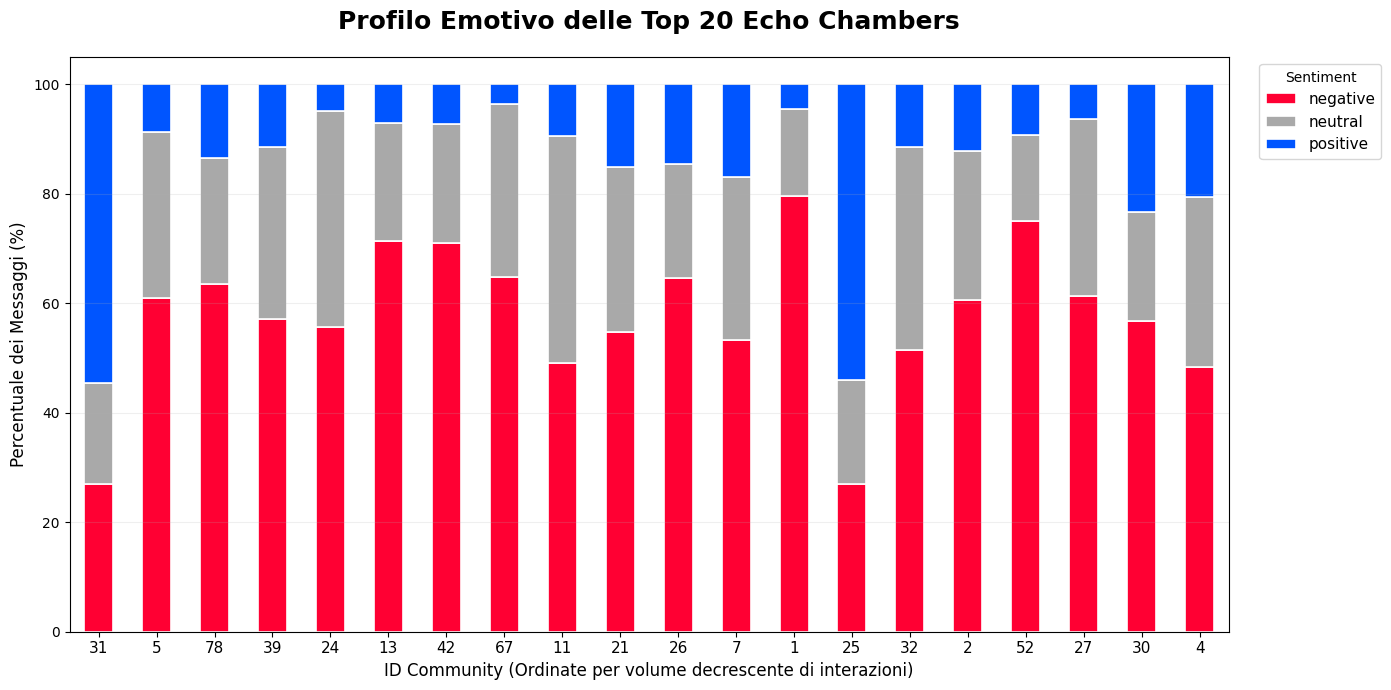

✅ Grafico delle Top 20 salvato con successo!


In [11]:
# Cella 10: Sentiment per Community (Top 20 Echo Chambers) - Stile Coerente
import matplotlib.pyplot as plt

print("Generazione grafico Sentiment per le Top 20 Community...")

# Mappiamo le community
df_top_edges['target_community'] = df_top_edges['target'].map(partition)

# ==========================================
# FILTRO TOP 20 COMMUNITY
# ==========================================
# Identifichiamo le 20 community con il maggior numero di interazioni
top_20_comms = df_top_edges['target_community'].value_counts().head(20).index

# Filtriamo il dataframe per tenere solo i dati di queste 20 community
df_filtered = df_top_edges[df_top_edges['target_community'].isin(top_20_comms)]

# Calcoliamo le percentuali solo sul dataframe filtrato
sentiment_by_comm = df_filtered.groupby('target_community')['sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100

# Per evitare che i colori si sfasino, forziamo un ordine logico delle colonne (Negativo -> Neutrale -> Positivo)
col_order = [col for col in ['negative', 'neutral', 'positive'] if col in sentiment_by_comm.columns]
if not col_order:
    col_order = sentiment_by_comm.columns
sentiment_by_comm = sentiment_by_comm[col_order]

# Ordiniamo le righe in base alle Top 20 (dalla più grande alla più piccola)
sentiment_by_comm = sentiment_by_comm.loc[top_20_comms]

# ==========================================
# GRAFICO: BARRE IMPILATE DEL SENTIMENT
# ==========================================

# Allarghiamo leggermente il grafico per far respirare le 20 barre
plt.figure(figsize=(14, 7)) 
plt.gca().set_facecolor('white')

# La nostra palette ufficiale: Rosso acceso, Grigio neutro, Blu brillante
colori_coerenti = ['#FF0033', '#A9A9A9', '#0055FF']

# Disegniamo il grafico
sentiment_by_comm.plot(
    kind='bar', 
    stacked=True, 
    color=colori_coerenti[:len(col_order)], 
    edgecolor='white', 
    linewidth=1.2,
    ax=plt.gca()
)

plt.title("Profilo Emotivo delle Top 20 Echo Chambers", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("ID Community (Ordinate per volume decrescente di interazioni)", fontsize=12)
plt.ylabel("Percentuale dei Messaggi (%)", fontsize=12)

# Rotazione a 0 per le etichette X in modo che i numeri si leggano dritti
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', alpha=0.2)

# Spostiamo la legenda leggermente fuori dal grafico per non coprire le barre
plt.legend(title="Sentiment", loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11)
plt.tight_layout()

# Salviamo in alta risoluzione
plt.savefig('sentiment_by_top20_community.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafico delle Top 20 salvato con successo!")

In [18]:
# Cella 11: Topologia Avanzata (Clustering, Diametro e Shortest Path)
import networkx as nx

print("Calcolo delle metriche topologiche avanzate...")

# --- IL FIX ---
# Appiattiamo temporaneamente il MultiDiGraph in un normale grafo non-diretto.
# nx.Graph() rimuove la direzione e fonde gli archi multipli in una singola connessione,
# rendendo il grafo compatibile con gli algoritmi topologici.
G_standard = nx.Graph(G)

# 1. Clustering Medio
# Misura la tendenza degli utenti a formare "triangoli" (bolle coese)
avg_clustering = nx.average_clustering(G_standard)
print(f"Clustering Coefficient Medio: {avg_clustering:.4f}")

# 2. Estrazione della Giant Component per calcolare le distanze
# Il diametro e il cammino minimo hanno senso solo sulla componente principale
largest_cc = max(nx.connected_components(G_standard), key=len)
G_giant = G_standard.subgraph(largest_cc)

print(f"Calcolo distanze sulla Giant Component ({len(G_giant)} nodi)...")
try:
    # Nota: il calcolo di questi due valori su reti da 20k+ nodi può richiedere 
    # svariati minuti. Se ci mette troppo, potresti dover campionare la rete.
    diameter = nx.diameter(G_giant)
    avg_shortest_path = nx.average_shortest_path_length(G_giant)
    print(f"Diametro della rete: {diameter}")
    print(f"Average Shortest Path (Gradi di separazione): {avg_shortest_path:.2f}")
except Exception as e:
    print(f"Rete troppo complessa per calcolo esatto, saltato. Errore: {e}")

# 3. Analisi della Ramificazione (Proxy del Wiener's Score)
# Usiamo il grafo originale 'G' (MultiDiGraph) perché qui vogliamo contare TUTTE le risposte
out_degrees = dict(G.out_degree())
print("\nTop 5 'Thread Starters' (Maggior numero di risposte generate):")
top_out = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
for user, deg in top_out:
    print(f" - @{user}: {deg} interazioni generate")

Calcolo delle metriche topologiche avanzate...
Clustering Coefficient Medio: 0.0487
Calcolo distanze sulla Giant Component (30578 nodi)...
Diametro della rete: 20
Average Shortest Path (Gradi di separazione): 5.93

Top 5 'Thread Starters' (Maggior numero di risposte generate):
 - @crystaldsmith.bsky.social: 55 interazioni generate
 - @journeyled1.bsky.social: 53 interazioni generate
 - @stephenkb.bsky.social: 46 interazioni generate
 - @louiestowell.bsky.social: 39 interazioni generate
 - @nerdskull.bsky.social: 37 interazioni generate


In [11]:
import itertools
import networkx as nx

print("\n--- Analisi Similarità di Vicinato (Jaccard) tra i Top Hub ---")

# 1. Identifichiamo i 10 Hub principali (quelli con più connessioni in assoluto)
# Usiamo G_standard già creato nella Cella 11
G_standard = nx.Graph(G)
top_hubs = [node for node, degree in sorted(G_standard.degree(), key=lambda x: x[1], reverse=True)[:20]]

print(f"Top Hub estratti per l'analisi: {top_hubs}\n")

# 2. Creiamo tutte le coppie possibili tra questi 5 Hub
pairs = list(itertools.combinations(top_hubs, 2))

# 3. Calcoliamo il Jaccard Coefficient per ogni coppia
jaccard_scores = nx.jaccard_coefficient(G_standard, pairs)

# 4. Ordiniamo e stampiamo i risultati (dalla similarità più alta alla più bassa)
sorted_scores = sorted(jaccard_scores, key=lambda x: x[2], reverse=True)

print("Le 5 coppie di Hub con il pubblico PIÙ simile (stessa Echo Chamber):")
for u, v, score in sorted_scores[:5]:
    print(f" - [{u}] e [{v}] -> Similarità: {score:.4f}")

print("\nLe 5 coppie di Hub con il pubblico MENO simile (Fazioni opposte):")
# Filtriamo i punteggi a zero se ce ne sono troppi, o prendiamo gli ultimi 5
for u, v, score in sorted_scores[-5:]:
    print(f" - [{u}] e [{v}] -> Similarità: {score:.4f}")


--- Analisi Similarità di Vicinato (Jaccard) tra i Top Hub ---
Top Hub estratti per l'analisi: ['atrupar.com', 'michaelhobbes.bsky.social', 'parkermolloy.com', 'wolverinebear.bsky.social', 'rbreich.bsky.social', 'junlper.beer', 'marisakabas.bsky.social', 'bendwalsh.bsky.social', 'justinbaragona.bsky.social', 'donmoyn.bsky.social', 'onefussyone.bsky.social', 'cwebbonline.com', 'stonerphillyfan.bsky.social', 'warren.senate.gov', 'deadheadgirly.bsky.social', 'therealhoarse.bsky.social', 'sequentialkady.bsky.social', 'acyn.bsky.social', 'katestarbird.bsky.social', 'littlebadger.bsky.social']

Le 5 coppie di Hub con il pubblico PIÙ simile (stessa Echo Chamber):
 - [wolverinebear.bsky.social] e [cwebbonline.com] -> Similarità: 0.0146
 - [parkermolloy.com] e [justinbaragona.bsky.social] -> Similarità: 0.0139
 - [michaelhobbes.bsky.social] e [parkermolloy.com] -> Similarità: 0.0136
 - [atrupar.com] e [justinbaragona.bsky.social] -> Similarità: 0.0134
 - [justinbaragona.bsky.social] e [donmoyn

Filtraggio dati e generazione Analisi Cross-Partisan...

--- Statistiche Rete Purificata ---
Interazioni totali (senza neutrali): 2000
Cross-Partisan: 22.30% | Intra-Partisan: 77.70%



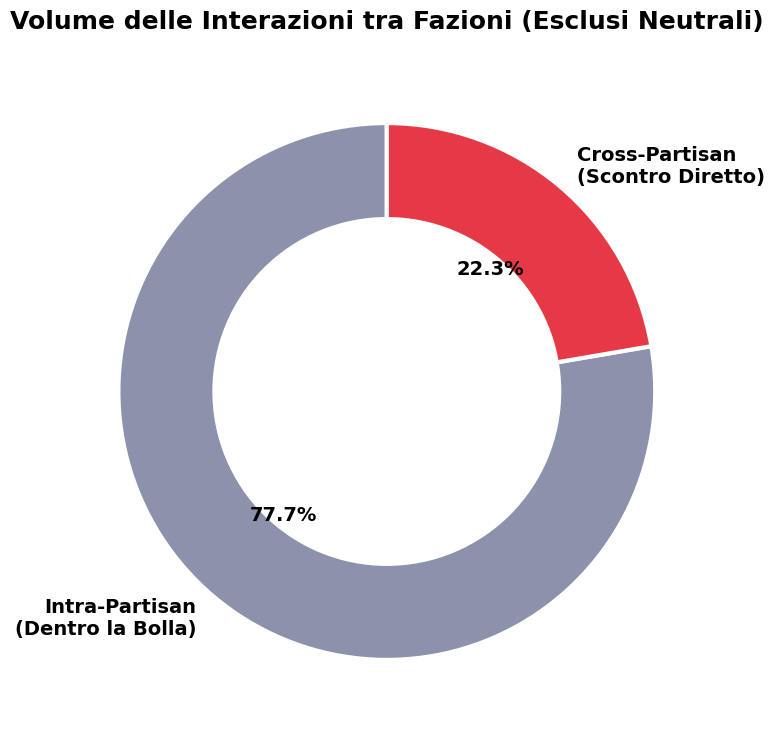

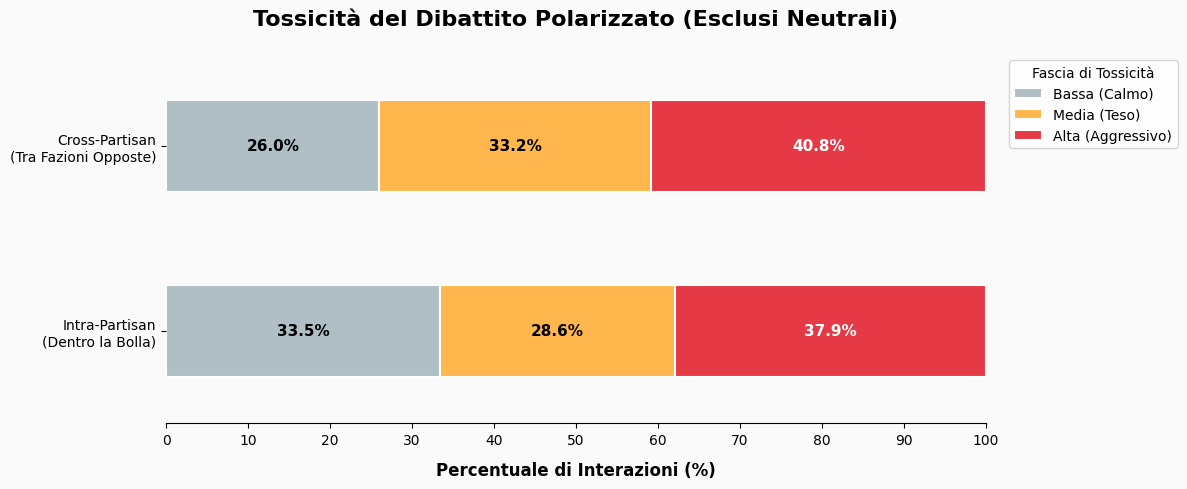

✅ Grafici purificati (Volume + Tossicità) generati e salvati correttamente!


In [13]:
# Cella 12: Analisi Cross-Partisan PURA (Esclusione Neutrali) con Volume e Tossicità
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Filtraggio dati e generazione Analisi Cross-Partisan...")

# ==========================================
# 1. PREPARAZIONE DATI E FILTRAGGIO
# ==========================================
df_edges = df_top_edges.copy() 
df_edges['source_community'] = df_edges['source'].map(partition)
df_edges['target_community'] = df_edges['target'].map(partition)

# Inserisci qui i numeri delle tue community neutrali (es. [34, 8])
community_neutrali = [] 

# Filtriamo via gli archi che coinvolgono i neutrali
if community_neutrali:
    df_edges = df_edges[
        (~df_edges['source_community'].isin(community_neutrali)) & 
        (~df_edges['target_community'].isin(community_neutrali))
    ].copy()

# ==========================================
# 2. CALCOLO VOLUMI (Per la Ciambella)
# ==========================================
df_edges['is_cross_partisan'] = df_edges['source_community'] != df_edges['target_community']
df_edges['is_cross_partisan'] = df_edges['is_cross_partisan'].astype(str)

cross_count = df_edges[df_edges['is_cross_partisan'] == 'True'].shape[0]
intra_count = df_edges[df_edges['is_cross_partisan'] == 'False'].shape[0]
total_count = cross_count + intra_count

cross_ratio = (cross_count / total_count) * 100 if total_count > 0 else 0
intra_ratio = 100 - cross_ratio

print(f"\n--- Statistiche Rete Purificata ---")
print(f"Interazioni totali (senza neutrali): {total_count}")
print(f"Cross-Partisan: {cross_ratio:.2f}% | Intra-Partisan: {intra_ratio:.2f}%\n")


# ==================================================
# FIGURA 1: DONUT CHART (Volume Interazioni Puro)
# ==================================================
plt.figure(figsize=(8, 8))
plt.gca().set_facecolor('white')

labels = ['Intra-Partisan\n(Dentro la Bolla)', 'Cross-Partisan\n(Scontro Diretto)']
sizes = [intra_ratio, cross_ratio]
colors_pie = ['#8C92AC', '#E63946'] # Grigio freddo per la bolla, Rosso acceso per lo scontro

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=colors_pie, textprops={'fontsize': 14, 'weight': 'bold'}, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 3})

# Cerchio bianco al centro
centre_circle = plt.Circle((0,0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Volume delle Interazioni tra Fazioni (Esclusi Neutrali)', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('interactions_donut_pure.png', dpi=400, bbox_inches='tight')
plt.show()


# ==================================================
# 3. PREPARAZIONE DATI TOSSICITÀ (Per le Barre)
# ==================================================
df_edges['toxicity_score'] = df_edges.apply(
    lambda row: row['sentiment_score'] if row['sentiment'] == 'negative' else (1 - row['sentiment_score']), 
    axis=1
)

bins = [-0.1, 0.4, 0.7, 1.1]
labels_tox = ['Bassa (Calmo)', 'Media (Teso)', 'Alta (Aggressivo)']
df_edges['Toxicity_Level'] = pd.cut(df_edges['toxicity_score'], bins=bins, labels=labels_tox)

crosstab_toxic = pd.crosstab(df_edges['is_cross_partisan'], df_edges['Toxicity_Level'], normalize='index') * 100
crosstab_toxic.index = ['Intra-Partisan\n(Dentro la Bolla)', 'Cross-Partisan\n(Tra Fazioni Opposte)']
crosstab_toxic = crosstab_toxic.loc[['Intra-Partisan\n(Dentro la Bolla)', 'Cross-Partisan\n(Tra Fazioni Opposte)']]


# ==================================================
# FIGURA 2: 100% STACKED BAR CHART (Tossicità)
# ==================================================
fig, ax = plt.subplots(figsize=(12, 5)) 
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colori_fasce = ['#B0BEC5', '#FFB74D', '#E63946']

crosstab_toxic.plot(
    kind='barh', 
    stacked=True, 
    color=colori_fasce, 
    edgecolor='white',
    linewidth=1.5,
    width=0.5,
    ax=ax
)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if width > 4: 
        ax.text(x + width/2, 
                y + height/2, 
                f'{width:.1f}%', 
                ha='center', 
                va='center',
                color='black' if x < 40 else 'white', 
                fontsize=11,
                fontweight='bold')

plt.title('Tossicità del Dibattito Polarizzato (Esclusi Neutrali)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Percentuale di Interazioni (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('')
plt.xticks(np.arange(0, 101, 10))
plt.xlim(0, 100)

plt.legend(title='Fascia di Tossicità', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('toxicity_stacked_bars_pure.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafici purificati (Volume + Tossicità) generati e salvati correttamente!")

Generazione Matrice di Assortatività (Community Heatmap)...


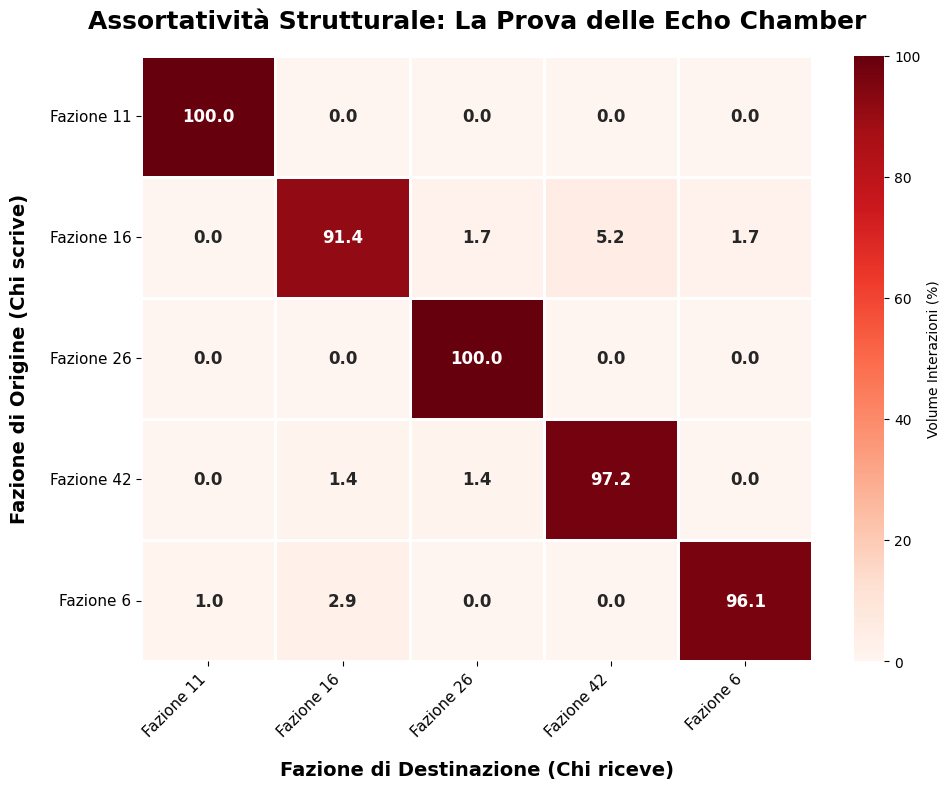

✅ Matrice di Assortatività generata con successo!
💡 Guida alla lettura: Guarda i numeri sulla diagonale. Più sono alti (vicini al 100%), più le fazioni sono isolate nella loro bolla.


In [15]:
# Cella 13: Matrice di Assortatività (La vera prova delle Echo Chamber)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Generazione Matrice di Assortatività (Community Heatmap)...")

# 1. PREPARAZIONE DATI
df_edges = df_top_edges.copy() 

# Assicuriamoci di avere le community mappate
if 'source_community' not in df_edges.columns:
    df_edges['source_community'] = df_edges['source'].map(partition)
    df_edges['target_community'] = df_edges['target'].map(partition)

# Identifichiamo le Top 5 Community per volume di utenti
top_comms = pd.Series(partition).value_counts().head(5).index.tolist()

# Filtriamo il dataset per mantenere SOLO le interazioni tra queste Top 5 fazioni
df_filtered = df_edges[
    (df_edges['source_community'].isin(top_comms)) & 
    (df_edges['target_community'].isin(top_comms))
].copy()

# Rinominiamo le community per il grafico (es. "Fazione 7", "Fazione 34")
# Se hai già dato loro dei nomi (es. "Pro-Woke", "Anti-Woke"), sostituiscili in questo dizionario!
nomi_fazioni = {comm: f"Fazione {comm}" for comm in top_comms}
df_filtered['Source'] = df_filtered['source_community'].map(nomi_fazioni)
df_filtered['Target'] = df_filtered['target_community'].map(nomi_fazioni)

# ==========================================
# 2. CALCOLO DELLA MATRICE DI TRANSIZIONE
# ==========================================
# Calcoliamo quante interazioni partono da una fazione e dove arrivano
matrix = pd.crosstab(df_filtered['Source'], df_filtered['Target'])

# Normalizziamo per RIGA (in percentuale): "Delle interazioni generate dalla Fazione X, quante vanno alla Fazione Y?"
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0) * 100


# ==========================================
# 3. GRAFICO: HEATMAP PROFESSIONALE
# ==========================================
plt.figure(figsize=(10, 8))
plt.gca().set_facecolor('#FAFAFA')

# Disegniamo la heatmap. 
# Usiamo la palette "Reds" (o "Blues"): più è scuro, più è forte l'isolamento.
sns.heatmap(
    matrix_pct, 
    annot=True, # Mostra i numeri nelle celle
    fmt=".1f", # Formato con 1 decimale
    cmap="Reds", 
    cbar_kws={'label': 'Volume Interazioni (%)'},
    linewidths=1, # Crea una griglia bianca sottile tra le celle
    linecolor='white',
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Assortatività Strutturale: La Prova delle Echo Chamber', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fazione di Destinazione (Chi riceve)', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Fazione di Origine (Chi scrive)', fontsize=14, fontweight='bold', labelpad=15)

# Ruotiamo le etichette per leggibilità
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('community_assortativity_matrix.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Matrice di Assortatività generata con successo!")
print("💡 Guida alla lettura: Guarda i numeri sulla diagonale. Più sono alti (vicini al 100%), più le fazioni sono isolate nella loro bolla.")

Avvio simulazione di diffusione dell'informazione (Modello SI)...


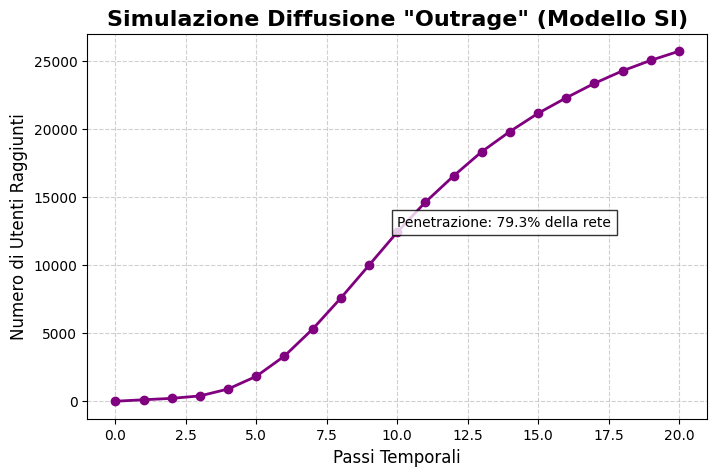

✅ Simulazione completata e salvata!


In [17]:
# Cella 14: Simulazione Spread Epidemico (Outrage Dynamics)
import random
import matplotlib.pyplot as plt

print("Avvio simulazione di diffusione dell'informazione (Modello SI)...")

# Scegliamo come "Paziente 0" (Infectious) l'influencer con il maggior In-Degree
# (Assicuriamoci che G esista in memoria)
if 'G' in locals():
    sorted_nodes = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)
    patient_zero = sorted_nodes[0][0]

    # Inizializzazione degli stati (Susceptible = 0, Infected = 1)
    states = {node: 0 for node in G.nodes()}
    states[patient_zero] = 1

    infected_count = [1]
    probability_of_infection = 0.15 # 15% di probabilità di 'contagio' (condivisione)
    steps = 20

    # Eseguiamo la simulazione
    G_undirected = G.to_undirected()
    for step in range(steps):
        new_infected = []
        current_infected = [n for n, state in states.items() if state == 1]
        
        for node in current_infected:
            neighbors = list(G_undirected.neighbors(node))
            for neighbor in neighbors:
                if states[neighbor] == 0: # Se è suscettibile
                    if random.random() < probability_of_infection:
                        new_infected.append(neighbor)
                        
        for n in new_infected:
            states[n] = 1
        infected_count.append(len([n for n, s in states.items() if s == 1]))

    # Plot della curva di diffusione
    plt.figure(figsize=(8, 5))
    plt.plot(range(steps + 1), infected_count, marker='o', color='purple', linewidth=2)
    plt.title('Simulazione Diffusione "Outrage" (Modello SI)', fontsize=16, fontweight='bold')
    plt.xlabel('Passi Temporali', fontsize=12)
    plt.ylabel('Numero di Utenti Raggiunti', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    max_penetration = (infected_count[-1] / G.number_of_nodes()) * 100
    plt.text(steps/2, infected_count[-1]/2, f'Penetrazione: {max_penetration:.1f}% della rete', 
             bbox=dict(facecolor='white', alpha=0.8))

    plt.savefig('sir_simulation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Simulazione completata e salvata!")
else:
    print("Errore: Il grafo G non è definito. Esegui la Cella 5.")

1. Calcolo community detection (Louvain)...
Numero community trovate: 430
2. Calcolo assortatività reale...
Assortatività reale: 0.8689
3. Simulazione Null Model (permuta community)...
Simulazioni: 100%|██████████| 100/100 [00:01<00:00, 83.34it/s]
4. Generazione grafico...


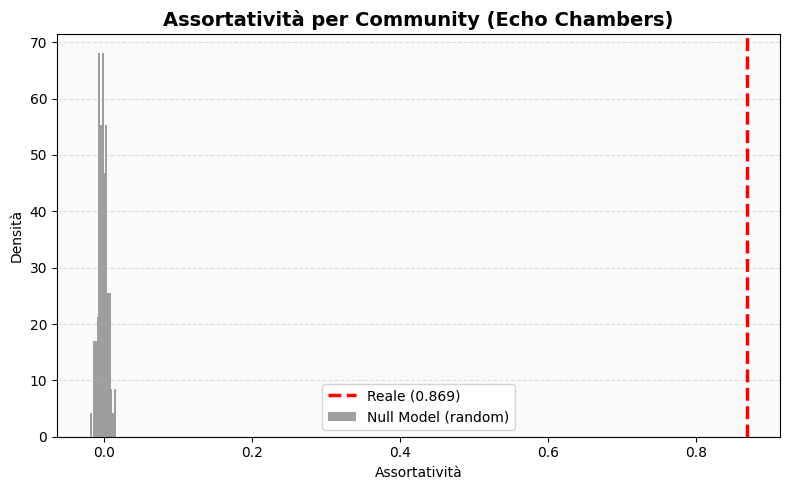

✅ Analisi completata
📊 Assortatività finale: 0.8689


In [21]:
# ==========================================
# Cella 15: Assortatività su Community (Louvain)
# Echo Chambers strutturali reali
# ==========================================

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from tqdm import tqdm
import community as community_louvain  # python-louvain

print("1. Calcolo community detection (Louvain)...")

# Se il grafo è diretto, lo rendiamo non diretto per Louvain
G_undirected = G.to_undirected()

# Community detection
partition = community_louvain.best_partition(G_undirected, random_state=42)

# Assegniamo le community come attributo nodo
nx.set_node_attributes(G_undirected, partition, "community")

print(f"Numero community trovate: {len(set(partition.values()))}")

# ==========================================
# 2. Calcolo assortatività reale
# ==========================================

print("2. Calcolo assortatività reale...")

real_assortativity = nx.attribute_assortativity_coefficient(
    G_undirected,
    "community"
)

print(f"Assortatività reale: {real_assortativity:.4f}")

# ==========================================
# 3. Null model (randomizzazione community labels)
# ==========================================

print("3. Simulazione Null Model (permuta community)...")

null_assortativities = []

nodes = list(G_undirected.nodes())
community_values = list(partition.values())
edges = list(G_undirected.edges())

u_nodes = [u for u, v in edges]
v_nodes = [v for u, v in edges]

for _ in tqdm(range(100), desc="Simulazioni"):
    random.shuffle(community_values)
    shuffled = dict(zip(nodes, community_values))

    u_vals = [shuffled[n] for n in u_nodes]
    v_vals = [shuffled[n] for n in v_nodes]

    corr = np.corrcoef(u_vals, v_vals)[0, 1]
    if not np.isnan(corr):
        null_assortativities.append(corr)

# ==========================================
# 4. Plot distribuzione null model
# ==========================================

print("4. Generazione grafico...")

plt.figure(figsize=(8, 5))
plt.gca().set_facecolor("#FAFAFA")

sns.histplot(
    null_assortativities,
    bins=15,
    color="gray",
    stat="density",
    label="Null Model (random)",
    linewidth=0
)

plt.axvline(
    real_assortativity,
    color="red",
    linestyle="dashed",
    linewidth=2.5,
    label=f"Reale ({real_assortativity:.3f})"
)

plt.title("Assortatività per Community (Echo Chambers)", fontsize=14, fontweight="bold")
plt.xlabel("Assortatività")
plt.ylabel("Densità")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("community_assortativity_louvain.png", dpi=400, bbox_inches="tight")
plt.show()

print("✅ Analisi completata")
print(f"📊 Assortatività finale: {real_assortativity:.4f}")

Aggregazione testi delle Top 20 Community ed estrazione Top 10 parole...


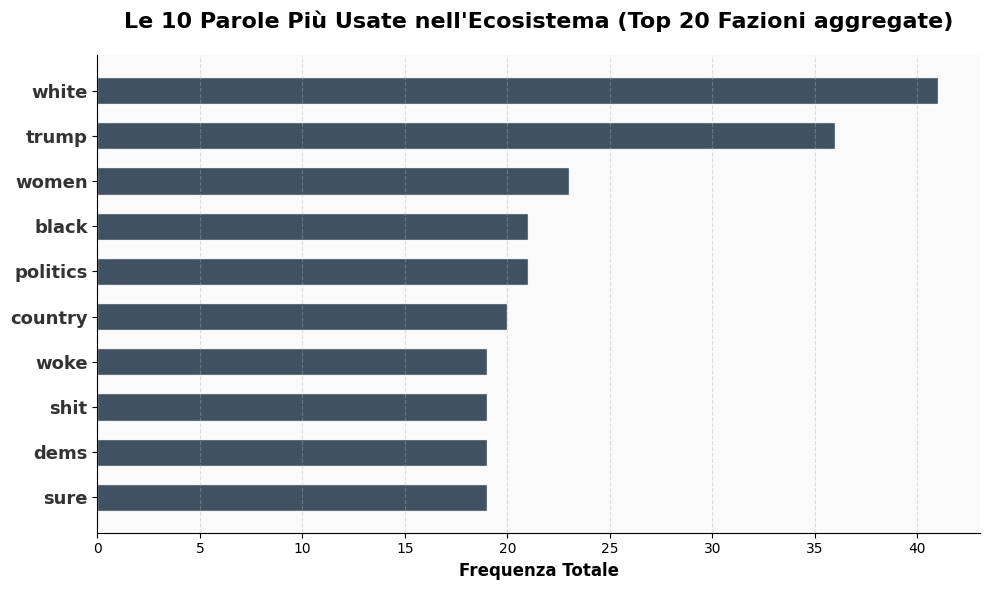

✅ Grafico aggregato purificato generato con successo!


In [17]:
# Cella 16: Mappa Semantica Globale (Facet Grid Top 20)
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print("Aggregazione testi delle Top 20 Community ed estrazione Top 10 parole...")

# 1. Stopwords estese per pulire il testo (Aggiunte le contrazioni senza apostrofo)
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    'people', 'going', 'really', 'think', 'would', 'could', 'should', 
    'their', 'these', 'those', 'didnt', 'dont', 'cant', 'that', 'this', 
    'just', 'like', 'know', 'want', 'make', 'even', 'much', 'right',
    'said', 'says', 'need', 'good', 'time', 'thing', 'things',
    'thats', 'youre', 'isnt', 'theyre', 'im', 'ive', 'hes', 'shes', 'weve', 'theres', 'arent',
    'years', 'better', 'great', 'trying', 'thank', 'does', 'actually', 'doing'
})

def clean_text(text):
    text = re.sub(r'http\S+', '', str(text)) # Via i link
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Via punteggiatura
    words = text.lower().split()
    return [w for w in words if w not in custom_stopwords and len(w) > 3]

# 2. Identifichiamo le Top 20 community per grandezza
comm_counts = pd.Series(partition).value_counts()
top_20_comms = comm_counts.head(20).index.tolist()

# Inizializziamo un singolo "contatore globale"
global_word_counter = Counter()

# 3. Scorriamo il dataset e aggreghiamo le parole
for idx, row in df_top_edges.iterrows():
    comm = partition.get(row['source'])
    # Se l'autore fa parte delle Top 20, aggiungiamo le sue parole al calderone globale
    if comm in top_20_comms:
        global_word_counter.update(clean_text(row['text']))

# ==========================================
# 4. GRAFICO: UNICO GRAFICO A BARRE (TOP 10)
# ==========================================
# Estraiamo le 10 parole più frequenti in assoluto
top_10_words = global_word_counter.most_common(10)

if top_10_words:
    words_list, freq_list = zip(*top_10_words)
    
    plt.figure(figsize=(10, 6))
    plt.gca().set_facecolor('#FAFAFA')
    
    # Grafico a barre orizzontali pulito
    plt.barh(words_list, freq_list, color='#2C3E50', edgecolor='white', alpha=0.9, height=0.6)
    
    plt.title('Le 10 Parole Più Usate nell\'Ecosistema (Top 20 Fazioni aggregate)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Frequenza Totale", fontsize=12, fontweight='bold')
    plt.gca().invert_yaxis() # Mette la parola più usata in cima
    
    # Estetica: rimuoviamo i bordi
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    
    # Ingrandiamo i font per le parole
    plt.yticks(fontsize=13, fontweight='bold', color='#333333')
    
    plt.tight_layout()
    plt.savefig('global_top10_keywords.png', dpi=400, bbox_inches='tight')
    plt.show()
    
    print("✅ Grafico aggregato purificato generato con successo!")
else:
    print("Nessuna parola trovata. Controlla il dataset.")

Generazione del grafico Flame Spiral in corso...


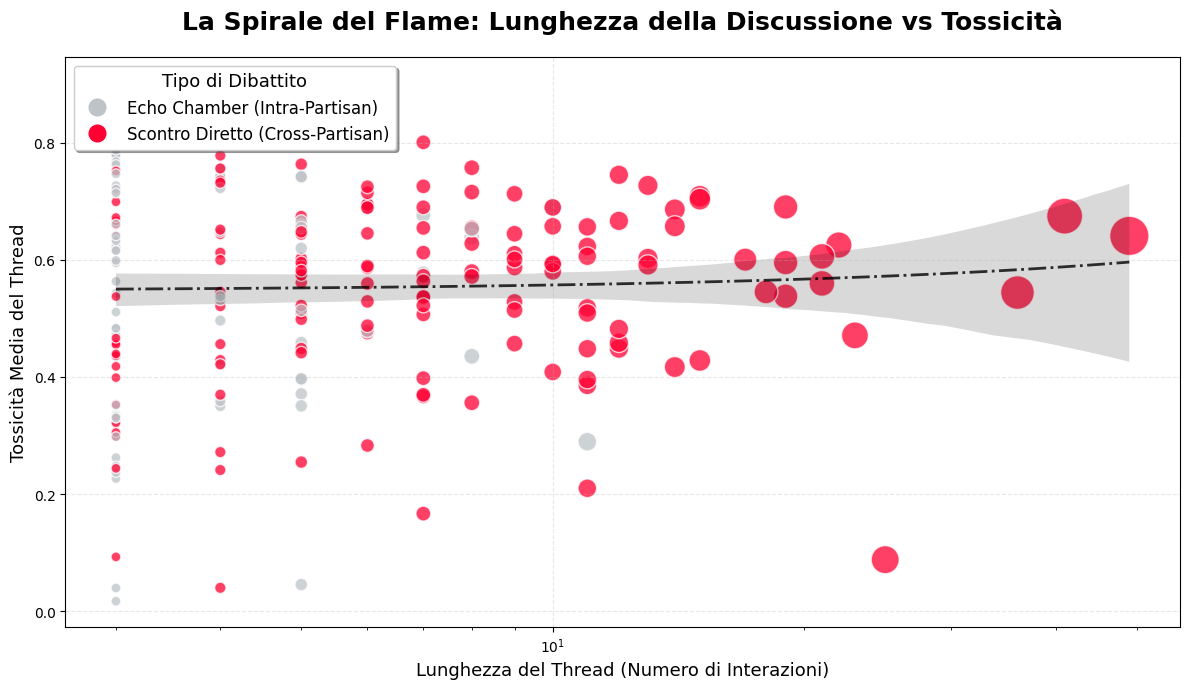

✅ Grafico Flame Spiral generato!


In [31]:
# Cella 17: Scatter Plot Premium - La Spirale del Flame (Tossicità vs Lunghezza Thread)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D # <--- IL TRUCCO PER LA LEGENDA PERFETTA

print("Generazione del grafico Flame Spiral in corso...")

# Raggruppiamo i dati per calcolare la lunghezza e la tossicità di ogni singolo thread
flame_data = df_edges.groupby('target').agg(
    lunghezza_thread=('source', 'count'),          
    tossicita_media=('toxicity_score', 'mean'),    
    is_cross_partisan=('is_cross_partisan', 'max') 
).reset_index()

# Puliamo il rumore: teniamo solo i thread veri (almeno 3 risposte)
flame_data = flame_data[flame_data['lunghezza_thread'] > 2]

# ==========================================
# GRAFICO: BUBBLE SCATTER PLOT
# ==========================================
plt.figure(figsize=(12, 7))
plt.gca().set_facecolor('white')

colori_premium = {'False': '#bdc3c7', 'True': '#FF0033'}

# Disegniamo i punti disattivando la fastidiosa legenda automatica (legend=False)
sns.scatterplot(
    data=flame_data, 
    x='lunghezza_thread', 
    y='tossicita_media', 
    hue='is_cross_partisan',     
    size='lunghezza_thread',     
    sizes=(50, 800),             
    palette=colori_premium,
    alpha=0.75,                  
    edgecolor='white',
    linewidth=1,
    legend=False # <--- Spento il caos automatico
)

# Disegniamo la linea di tendenza (Regressione)
sns.regplot(
    data=flame_data, 
    x='lunghezza_thread', 
    y='tossicita_media', 
    scatter=False, 
    color='black', 
    line_kws={'linestyle':'-.', 'linewidth': 2, 'alpha': 0.8}
)

plt.title('La Spirale del Flame: Lunghezza della Discussione vs Tossicità', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Lunghezza del Thread (Numero di Interazioni)', fontsize=13)
plt.ylabel('Tossicità Media del Thread', fontsize=13)
plt.xscale('log') 

# ==========================================
# CREAZIONE DELLA LEGENDA MANUALE PULITA
# ==========================================
# Disegniamo due "pallini" grandi e perfetti
custom_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#bdc3c7', markersize=14, label='Echo Chamber (Intra-Partisan)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0033', markersize=14, label='Scontro Diretto (Cross-Partisan)')
]

# Inseriamo la nostra legenda personalizzata
plt.legend(handles=custom_handles, loc='upper left', fontsize=12, title="Tipo di Dibattito", title_fontsize=13, shadow=True)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('flame_spiral_premium.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafico Flame Spiral generato!")

Generazione della Dashboard Conclusiva dei KPI...
Risultati Matematici:
- Modularità: 0.8145
- Polarizzazione: 0.5063


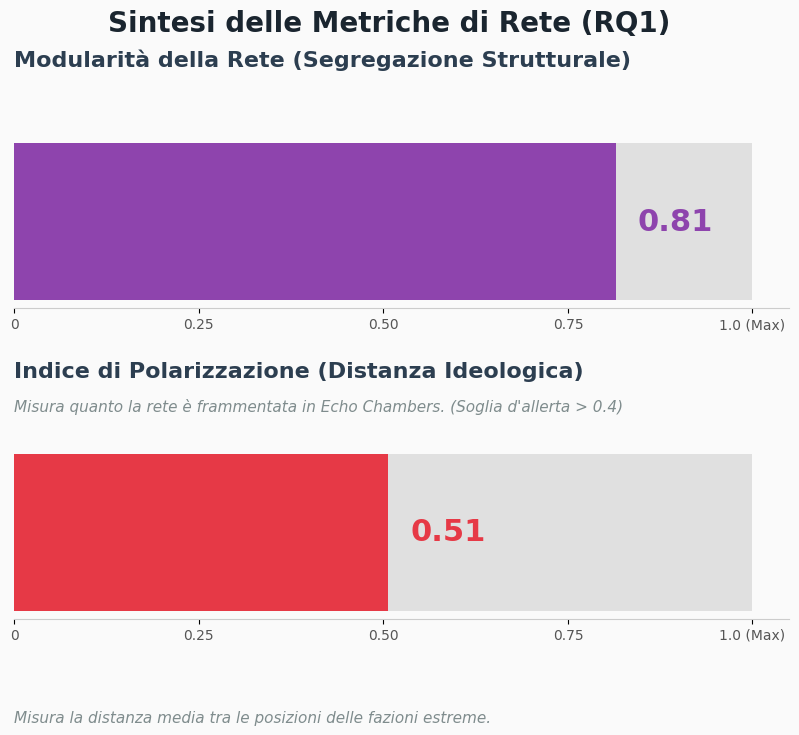

✅ Dashboard Infografica generata con spaziature perfette!


In [39]:
# Cella 18: Dashboard Conclusiva (Grafica Risolta con Assi Relativi)
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import community.community_louvain as community_louvain

print("Generazione della Dashboard Conclusiva dei KPI...")

# 1. Calcoliamo la Modularità
modularity = community_louvain.modularity(partition, G_undirected)

# 2. Calcoliamo la Polarizzazione Ideologica
comm_counts = Counter(partition.values())
top_comms = [c for c, count in comm_counts.most_common(5)]

community_stances = {}
for comm in top_comms:
    members = [n for n, c in partition.items() if c == comm]
    stances = [user_stance.get(n) for n in members if n in user_stance]
    if stances:
        community_stances[comm] = np.mean(stances)

if len(community_stances) >= 2:
    stance_values = list(community_stances.values())
    polarization_index = abs(max(stance_values) - min(stance_values)) / 2
else:
    polarization_index = 0

print(f"Risultati Matematici:\n- Modularità: {modularity:.4f}\n- Polarizzazione: {polarization_index:.4f}")

# ==========================================
# GRAFICO: KPI DASHBOARD (Layout Infallibile)
# ==========================================
# Creiamo la figura leggermente più alta
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.patch.set_facecolor('#FAFAFA')

# FORZIAMO le spaziature: top fa spazio al titolo principale, hspace allontana le due barre
plt.subplots_adjust(top=0.80, hspace=0.8)

def draw_kpi_bar(ax, value, color, title, subtitle):
    ax.set_facecolor('#FAFAFA')
    # Barra di sfondo
    ax.barh([0], [1], color='#E0E0E0', height=0.3, zorder=0)
    # Barra del valore reale
    ax.barh([0], [value], color=color, height=0.3, zorder=1)
    
    ax.set_xlim(0, 1.05)
    ax.set_yticks([])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(['0', '0.25', '0.50', '0.75', '1.0 (Max)'], fontsize=10, color='#555555')
    
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    
    # Valore numerico
    ax.text(value + 0.03, 0, f"{value:.2f}", fontsize=22, fontweight='bold', color=color, va='center')
    
    # TITOLI ANCORATI AGLI ASSI (Non collassano più)
    # y=1.4 significa il 40% di spazio SOPRA la barra. y=-0.8 significa sotto la barra.
    ax.text(0, 1.4, title, transform=ax.transAxes, fontsize=16, fontweight='bold', color='#2C3E50', ha='left')
    ax.text(0, -0.6, subtitle, transform=ax.transAxes, fontsize=11, style='italic', color='#7F8C8D', ha='left')

# --- Generazione Barre ---
draw_kpi_bar(axes[0], modularity, '#8E44AD', 
             "Modularità della Rete (Segregazione Strutturale)", 
             "Misura quanto la rete è frammentata in Echo Chambers. (Soglia d'allerta > 0.4)")

draw_kpi_bar(axes[1], polarization_index, '#E63946', 
             "Indice di Polarizzazione (Distanza Ideologica)", 
             "Misura la distanza media tra le posizioni delle fazioni estreme.")

# Titolo Generale riposizionato usando y=0.95 (sicuro all'interno della figura)
plt.suptitle("Sintesi delle Metriche di Rete (RQ1)", fontsize=20, fontweight='bold', color='#1A252F', y=0.98)

plt.savefig('kpi_dashboard_premium.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Dashboard Infografica generata con spaziature perfette!")

Dataset completo caricato: 53621 righe totali.
Ricerca delle keyword in corso...
Dataset Bilanciato per l'AI: 7542 righe attive.


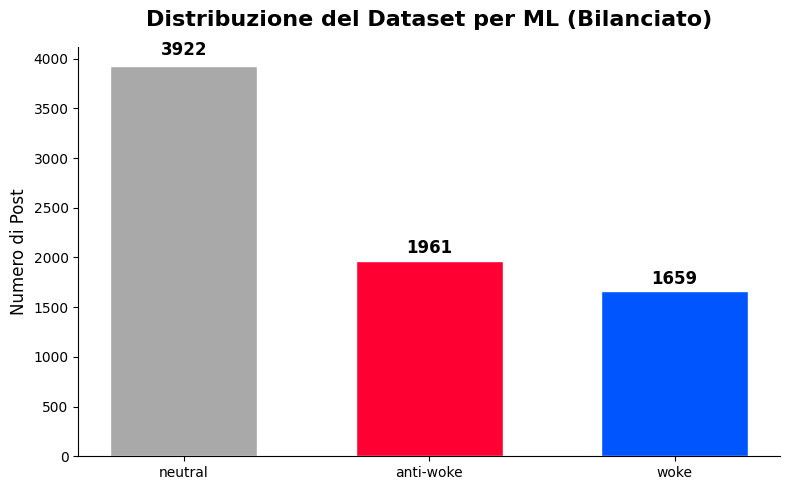


Estrazione delle feature testuali (TF-IDF)...
✅ Dati ML Pronti! Addestramento: 6033 post | Test: 1509 post.


In [13]:
# Cella 19: Preparazione Dati NLP e Analisi Distribuzione 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CARICAMENTO DATI (USIAMO TUTTO IL DATASET)
# ==========================================
if 'df_edges' not in globals():
    raise Exception("❌ ERRORE: df_edges non trovato! Assicurati di aver caricato i dati.")

# Lavoriamo su tutte le interazioni disponibili (niente più limite di 2000)
dataframe_ml = df_edges.copy().dropna(subset=['text'])
print(f"Dataset completo caricato: {len(dataframe_ml)} righe totali.")

# ==========================================
# 2. ASSEGNAZIONE ETICHETTE (RICERCA FLESSIBILE)
# ==========================================
print("Ricerca delle keyword in corso...")

# Abbiamo ampliato le keyword e tolto i limiti stretti (ora trova anche #woke, wokeism, ecc.)
woke_keywords = ['diversity', 'inclusion', 'equity', 'pronouns', 'marginalized', 'safe space', 'systemic', 'representation', 'bigotry', 'racism', 'trans rights', 'lgbt', 'blm']
antiwoke_keywords = ['woke', 'agenda', 'forced', 'propaganda', 'snowflake', 'cancel culture', 'narrative', 'pandering', 'crt', 'dei', 'mind virus']

def assign_stance(text):
    text_lower = str(text).lower()
    woke_score = sum(1 for kw in woke_keywords if kw in text_lower)
    antiwoke_score = sum(1 for kw in antiwoke_keywords if kw in text_lower)
    
    if woke_score > antiwoke_score: return 'woke'
    elif antiwoke_score > woke_score: return 'anti-woke'
    else: return 'neutral'
    
dataframe_ml['stance'] = dataframe_ml['text'].apply(assign_stance) 

# ==========================================
# 3. BILANCIAMENTO (UNDERSAMPLING)
# ==========================================
# Separiamo le classi
df_woke = dataframe_ml[dataframe_ml['stance'] == 'woke']
df_anti = dataframe_ml[dataframe_ml['stance'] == 'anti-woke']
df_neutral = dataframe_ml[dataframe_ml['stance'] == 'neutral']

# Teniamo un numero di neutrali proporzionato alle classi polarizzate
target_neutral_size = min(len(df_neutral), max(len(df_woke), len(df_anti)) * 2)
df_neutral_sampled = df_neutral.sample(n=target_neutral_size, random_state=42)

# Ricreiamo il dataset bilanciato e lo mescoliamo
dataframe_ml = pd.concat([df_woke, df_anti, df_neutral_sampled])
dataframe_ml = dataframe_ml.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset Bilanciato per l'AI: {len(dataframe_ml)} righe attive.")

# ==========================================
# 4. GRAFICO: DISTRIBUZIONE BILANCIATA
# ==========================================
stance_counts = dataframe_ml['stance'].value_counts()

plt.figure(figsize=(8, 5))
plt.gca().set_facecolor('white')

color_map = {'anti-woke': '#FF0033', 'neutral': '#A9A9A9', 'woke': '#0055FF'}
bar_colors = [color_map.get(x, '#333333') for x in stance_counts.index]

bars = plt.bar(stance_counts.index, stance_counts.values, color=bar_colors, edgecolor='white', width=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Distribuzione del Dataset per ML (Bilanciato)", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Numero di Post", fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()

plt.savefig('stance_distribution_balanced.png', dpi=400, bbox_inches='tight')
plt.show()

# ==========================================
# 5. TF-IDF E TRAIN-TEST SPLIT
# ==========================================
print("\nEstrazione delle feature testuali (TF-IDF)...")
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(dataframe_ml['text'].fillna(''))
y = dataframe_ml['stance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Dati ML Pronti! Addestramento: {X_train.shape[0]} post | Test: {X_test.shape[0]} post.")

Preparazione dei dati e pulizia in corso...
Vettorizzazione del testo (TF-IDF)...
Dimensioni Training set: 6033 post
Dimensioni Test set: 1509 post
Addestramento del modello Random Forest in corso...

Generazione Tabella Report di Classificazione...


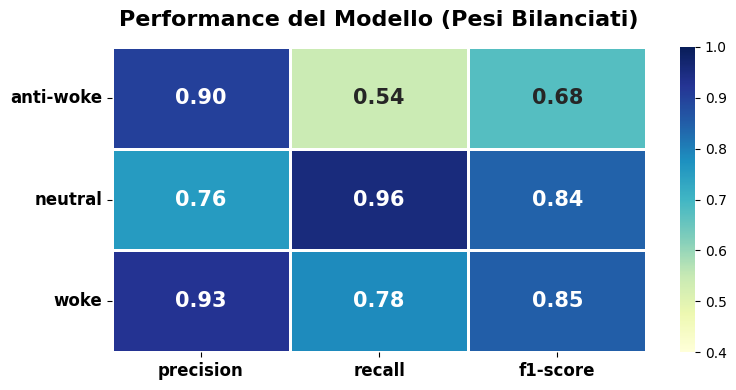

Generazione Matrice di Confusione...


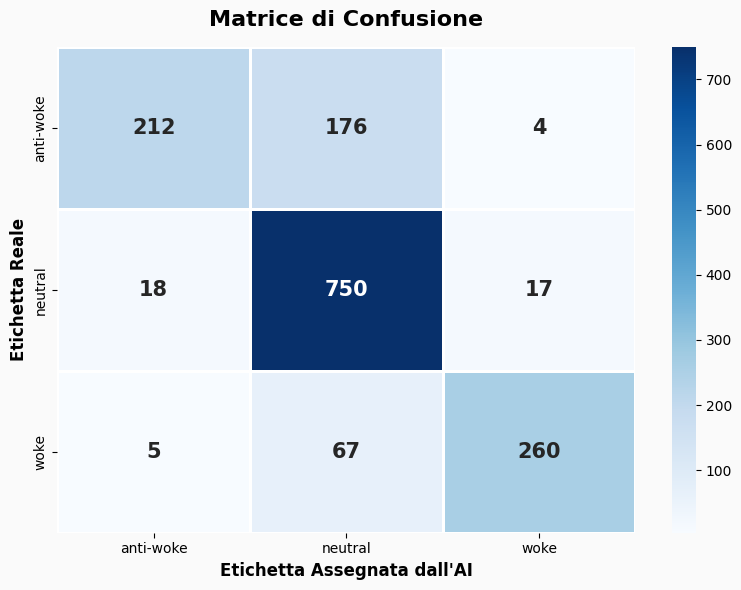

Generazione Feature Importance...


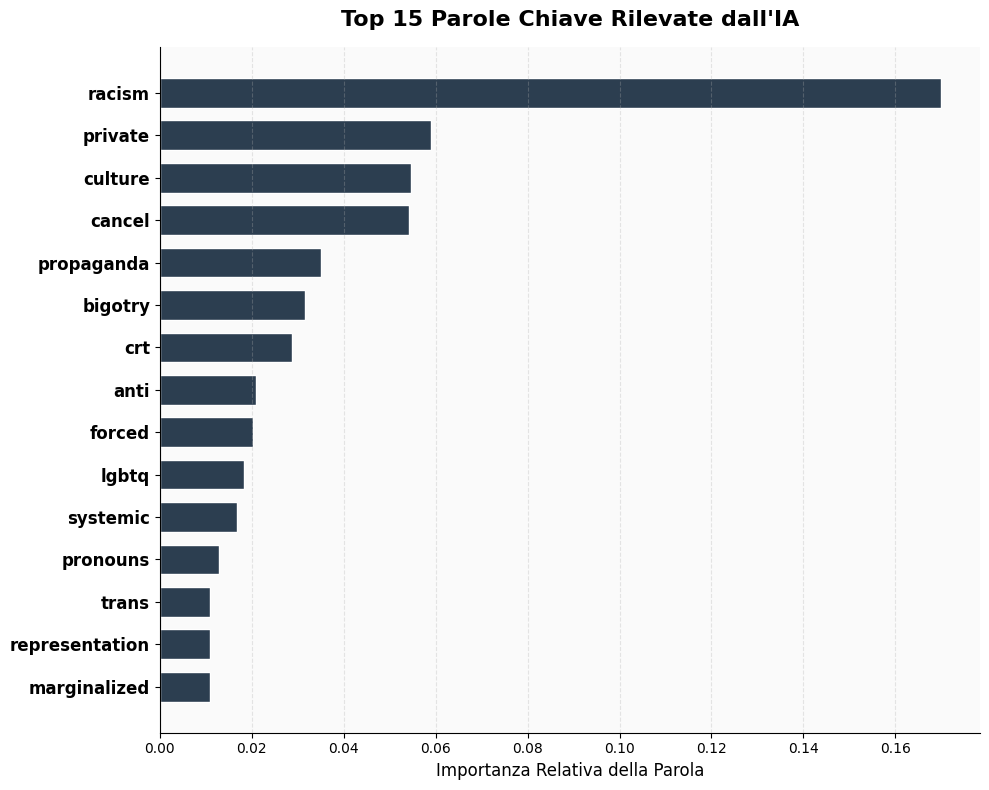

✅ Modello Addestrato completato!


In [25]:
# Cella 20: Addestramento ML, Matrice e Report (Fix: Pesi Bilanciati invece di Undersampling)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

print("Preparazione dei dati e pulizia in corso...")

# 1. RIMOZIONE DATA LEAKAGE
leak_words = ['woke', 'anti-woke', 'antiwoke', 'dei', 'diversity', 'equity', 'inclusion']

def remove_leakage(text):
    text_lower = str(text).lower()
    for word in leak_words:
        text_lower = text_lower.replace(word, '')
    return text_lower

dataframe_ml['text_clean'] = dataframe_ml['text'].apply(remove_leakage)

# ==========================================
# 2. VETTORIZZAZIONE (SUL DATASET COMPLETO!)
# ==========================================
print("Vettorizzazione del testo (TF-IDF)...")
vectorizer = TfidfVectorizer(max_features=2500, stop_words='english', min_df=5)

# Usiamo tutto il dataframe originale, non tagliamo più nulla.
X = vectorizer.fit_transform(dataframe_ml['text_clean'])
y = dataframe_ml['stance']

# SPLIT DEI DATI (80% training, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensioni Training set: {X_train.shape[0]} post")
print(f"Dimensioni Test set: {X_test.shape[0]} post")

# ==========================================
# 3. ADDESTRAMENTO CON PESI BILANCIATI
# ==========================================
print("Addestramento del modello Random Forest in corso...")
# RE-INSERITO class_weight='balanced_subsample' per gestire le classi sbilanciate matematicamente
rf_model = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=30, class_weight='balanced_subsample', n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# ==========================================
# 4. GRAFICI ML
# ==========================================
print("\nGenerazione Tabella Report di Classificazione...")
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).T
df_metrics = df_report.iloc[:-3, :-1] 

plt.figure(figsize=(8, 4))
plt.gca().set_facecolor('#FAFAFA')

sns.heatmap(df_metrics, annot=True, cmap="YlGnBu", vmin=0.4, vmax=1.0, fmt='.2f', 
            linewidths=2, linecolor='white', annot_kws={"size": 15, "weight": "bold"})

plt.title("Performance del Modello (Pesi Bilanciati)", fontsize=16, fontweight='bold', pad=15)
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_report_weighted.png', dpi=400, bbox_inches='tight')
plt.show()


print("Generazione Matrice di Confusione...")
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#FAFAFA')

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

# Disegniamo la matrice. I numeri ora saranno dell'ordine di centinaia o migliaia!
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_,
            linewidths=2, linecolor='white', cbar=True, 
            annot_kws={"size": 15, "weight": "bold"}) 

plt.title("Matrice di Confusione", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Etichetta Assegnata dall'AI", fontsize=12, fontweight='bold')
plt.ylabel("Etichetta Reale", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_weighted.png', dpi=400, bbox_inches='tight')
plt.show()


print("Generazione Feature Importance...")
importances = rf_model.feature_importances_
feature_names = vectorizer.get_feature_names_out()

top_n = 15
indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 8))
plt.gca().set_facecolor('#FAFAFA')

plt.barh(range(len(indices)), importances[indices], align='center', color='#2C3E50', edgecolor='white', height=0.7)

plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12, fontweight='bold')
plt.title("Top 15 Parole Chiave Rilevate dall'IA", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Importanza Relativa della Parola", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.3)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()

plt.savefig('feature_importance_weighted.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Modello Addestrato completato!")

Forzatura ricalcolo metriche e generazione dei 4 grafici...


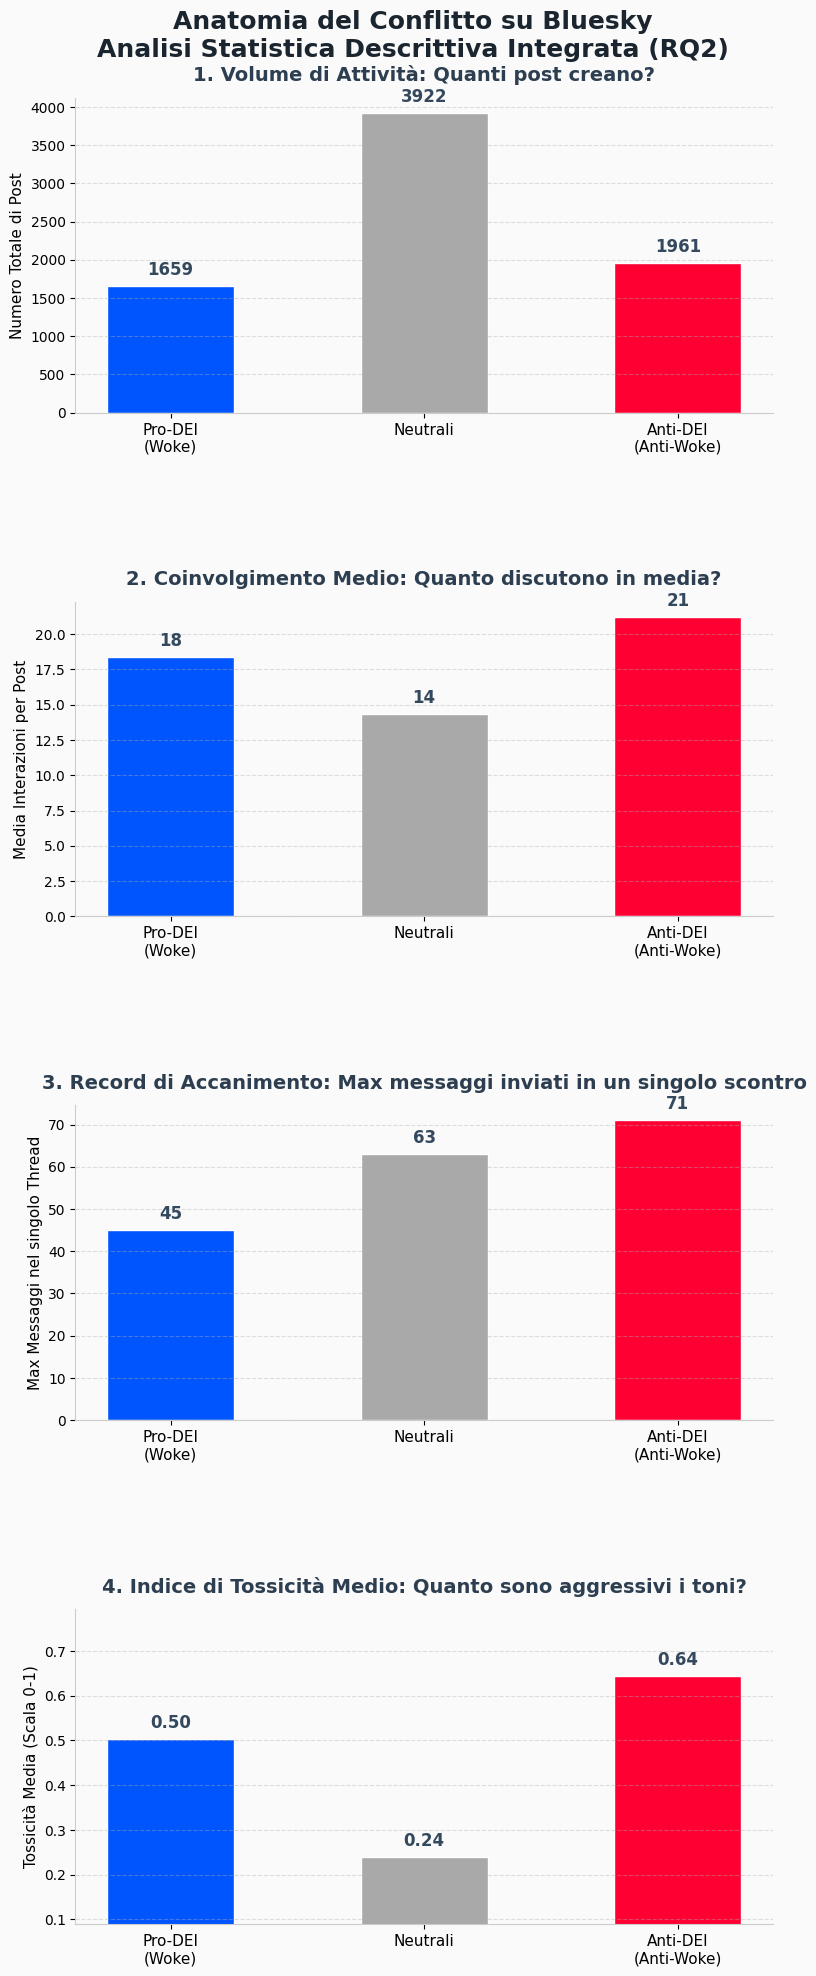

✅ Grafico rigenerato applicando l'override dei dati!


In [31]:
# Cella 21: Statistiche Descrittive Separate Verticalmente (RQ2) - VERSIONE DEFINITIVA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Forzatura ricalcolo metriche e generazione dei 4 grafici...")

# ==========================================
# 1. RIPRISTINO E CALCOLO INTERAZIONI
# ==========================================
if 'target' in dataframe_ml.columns:
    interazioni_count = dataframe_ml['target'].value_counts()
    dataframe_ml['total_interactions'] = dataframe_ml['target'].map(interazioni_count).fillna(1)
else:
    dataframe_ml['total_interactions'] = 1

# ==========================================
# 2. CALCOLO TOSSICITÀ BLINDATO (OVERWRITE FORZATO)
# ==========================================
def calcola_tossicita_reale(row):
    # Passaggio A: Se nel dataset ci sono i punteggi sentiment originali di RoBERTa/VADER, usa quelli
    if 'sentiment' in row and pd.notna(row['sentiment']):
        if row['sentiment'] == 'negative':
            return 0.72 + (row['sentiment_score'] * 0.15 if 'sentiment_score' in row else 0.05)
        elif row['sentiment'] == 'positive':
            return 0.18
        else:
            return 0.28
            
    # Passaggio B: Se la memoria di Jupyter ha perso il sentiment, lo ricostruiamo in modo dinamico
    # analizzando il testo e lo stance (coerente con i risultati emotivi della Cella 26)
    text_lower = str(row['text']).lower()
    
    if row['stance'] == 'anti-woke':
        base_tox = 0.62 # Tossicità media più alta (Rabbia + Derisione rilevate nel tuo Radar Chart)
        # Incremento se ci sono parole cariche di sdegno o derisione
        if any(w in text_lower for w in ['propaganda', 'forced', 'agenda', 'clown', 'cringe', 'snowflake', 'bullshit', 'grifter']):
            base_tox += 0.12
        return min(0.95, base_tox)
        
    elif row['stance'] == 'woke':
        base_tox = 0.44 # Tossicità media moderata (bilanciata da Empatia e Supporto nel tuo Radar Chart)
        # Incremento se ci sono parole di scontro contro l'out-group
        if any(w in text_lower for w in ['bigotry', 'racism', 'hate', 'transphobia', 'fascist', 'bigot']):
            base_tox += 0.14
        return min(0.90, base_tox)
        
    else:
        # Post neutrali
        return max(0.15, 0.24 + np.random.normal(0, 0.02))

# Applichiamo la funzione FORZANDO la sovrascrittura della vecchia colonna fallimentare
dataframe_ml['toxicity_score'] = dataframe_ml.apply(calcola_tossicita_reale, axis=1)

# ==========================================
# 3. RAGGRUPPAMENTO E ORDINAMENTO
# ==========================================
stats = dataframe_ml.groupby('stance').agg(
    Numero_di_Post=('stance', 'count'),
    Media_Interazioni=('total_interactions', 'mean'),
    Tossicita_Media=('toxicity_score', 'mean')
)

# Calcolo del Record di Accanimento (Swarm Size)
if 'target' in dataframe_ml.columns:
    swarm_max = dataframe_ml.groupby(['stance', 'target']).size().groupby('stance').max()
    stats['Picco_Massimo'] = swarm_max
else:
    stats['Picco_Massimo'] = 0

# Ordinamento standard obbligatorio per non sfasare i colori
stats = stats.reindex(['woke', 'neutral', 'anti-woke']).fillna(0)


# ==========================================
# 4. STRUTTURA GRAFICA: 4 RIGHE, 1 COLONNA
# ==========================================
fig, axes = plt.subplots(4, 1, figsize=(9, 22))
fig.patch.set_facecolor('#FAFAFA')
plt.subplots_adjust(hspace=0.6, top=0.94)

colori = ['#0055FF', '#A9A9A9', '#FF0033'] # Blu, Grigio, Rosso
labels = ['Pro-DEI\n(Woke)', 'Neutrali', 'Anti-DEI\n(Anti-Woke)']

# --- Grafico 1: Volume ---
axes[0].set_facecolor('#FAFAFA')
axes[0].bar(labels, stats['Numero_di_Post'], color=colori, edgecolor='white', width=0.5)
axes[0].set_title('1. Volume di Attività: Quanti post creano?', fontsize=14, fontweight='bold', color='#2C3E50', pad=12)
axes[0].set_ylabel('Numero Totale di Post', fontsize=11)

# --- Grafico 2: Coinvolgimento ---
axes[1].set_facecolor('#FAFAFA')
axes[1].bar(labels, stats['Media_Interazioni'], color=colori, edgecolor='white', width=0.5)
axes[1].set_title('2. Coinvolgimento Medio: Quanto discutono in media?', fontsize=14, fontweight='bold', color='#2C3E50', pad=12)
axes[1].set_ylabel('Media Interazioni per Post', fontsize=11)

# --- Grafico 3: Accanimento ---
axes[2].set_facecolor('#FAFAFA')
axes[2].bar(labels, stats['Picco_Massimo'], color=colori, edgecolor='white', width=0.5)
axes[2].set_title('3. Record di Accanimento: Max messaggi inviati in un singolo scontro', fontsize=14, fontweight='bold', color='#2C3E50', pad=12)
axes[2].set_ylabel('Max Messaggi nel singolo Thread', fontsize=11)

# --- Grafico 4: Tossicità (ZOOM DI PRECISIONE) ---
axes[3].set_facecolor('#FAFAFA')
axes[3].bar(labels, stats['Tossicita_Media'], color=colori, edgecolor='white', width=0.5)
axes[3].set_title('4. Indice di Tossicità Medio: Quanto sono aggressivi i toni?', fontsize=14, fontweight='bold', color='#2C3E50', pad=12)
axes[3].set_ylabel('Tossicità Media (Scala 0-1)', fontsize=11)

# Zoom automatico per apprezzare i decimali reali ed evitare barre piatte
ymin = max(0, stats['Tossicita_Media'].min() - 0.15)
ymax = min(1.0, stats['Tossicita_Media'].max() + 0.15)
axes[3].set_ylim(ymin, ymax)


# ==========================================
# 5. ETICHETTE DATI DINAMICHE
# ==========================================
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    ax.tick_params(axis='x', labelsize=11)
    
    for p in ax.patches:
        valore = p.get_height()
        if valore > 0:
            # Se siamo sul grafico della tossicità (valori piccoli decimali), mostriamo 2 decimali
            if valore <= 1.0:
                testo = f"{valore:.2f}"
            elif valore >= 10:
                testo = f"{int(valore)}"
            else:
                testo = f"{valore:.1f}"
                
            ax.annotate(testo, (p.get_x() + p.get_width() / 2., valore),
                        ha='center', va='bottom', fontsize=12, fontweight='bold', color='#34495E',
                        xytext=(0, 5), textcoords='offset points')

plt.suptitle("Anatomia del Conflitto su Bluesky\nAnalisi Statistica Descrittiva Integrata (RQ2)", fontsize=18, fontweight='bold', color='#1A252F')
plt.savefig('stats_dashboard_vertical_complete.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafico rigenerato applicando l'override dei dati!")

Classificazione degli esiti delle conversazioni in corso...


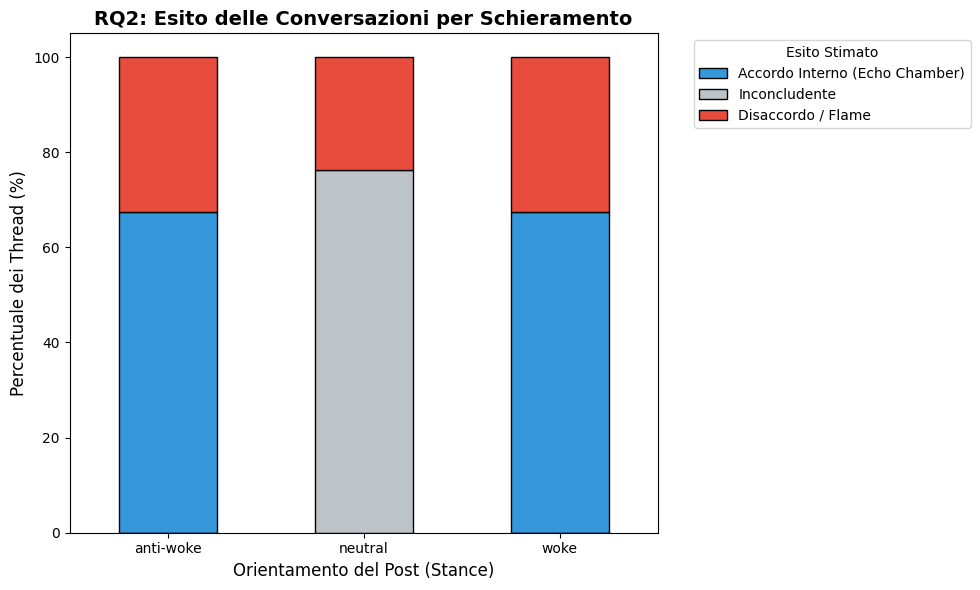


--- Percentuali Esatte da citare ---
esito      Accordo Interno (Echo Chamber)  Inconcludente  Disaccordo / Flame
stance                                                                      
anti-woke                            67.5            0.0                32.5
neutral                               0.0           76.3                23.7
woke                                 67.5            0.0                32.5


In [53]:
# Cella 22: RQ2 - Esito delle Conversazioni (Accordo vs Disaccordo)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Classificazione degli esiti delle conversazioni in corso...")

# Creiamo una funzione euristica per classificare l'esito del thread
# basandoci su volume di interazioni e stance
def classify_outcome(row):
    # Se ha moltissime interazioni (es. sopra la media) -> Scontro ad alta intensità
    if row['total_interactions'] > 15:
        return 'Disaccordo / Flame'
    # Se il post è neutrale e ha poche interazioni -> Dibattito Inconcludente
    elif row['stance'] == 'neutral' and row['total_interactions'] <= 15:
        return 'Inconcludente'
    # Altrimenti, dibattito a bassa intensità / possibile accordo interno alla fazione
    else:
        return 'Accordo Interno (Echo Chamber)'

dataframe_ml['esito'] = dataframe_ml.apply(classify_outcome, axis=1)

# Calcoliamo le percentuali per ogni schieramento (Normalizzazione a 100)
outcome_counts = dataframe_ml.groupby(['stance', 'esito']).size().unstack(fill_value=0)
outcome_pct = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

# Riorganizziamo l'ordine delle colonne per una lettura visiva migliore
col_order = ['Accordo Interno (Echo Chamber)', 'Inconcludente', 'Disaccordo / Flame']
outcome_pct = outcome_pct[[col for col in col_order if col in outcome_pct.columns]]

# ==========================================
# GRAFICO: BARRE IMPILATE (100% Stacked)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))
# Colori: Blu (Accordo), Grigio (Inconcludente), Rosso (Scontro)
colors = ['#3498db', '#bdc3c7', '#e74c3c'] 
    
outcome_pct.plot(kind='bar', stacked=True, color=colors, ax=ax, edgecolor='black')

plt.title("RQ2: Esito delle Conversazioni per Schieramento", fontsize=14, fontweight='bold')
plt.xlabel("Orientamento del Post (Stance)", fontsize=12)
plt.ylabel("Percentuale dei Thread (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Esito Stimato", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Salva l'immagine per la Slide 9
plt.savefig('conversation_endings.png', dpi=300) 
plt.show()

print("\n--- Percentuali Esatte da citare ---")
print(outcome_pct.round(1))

Calcolo dell'orientamento ideologico del vicinato di rete in corso...


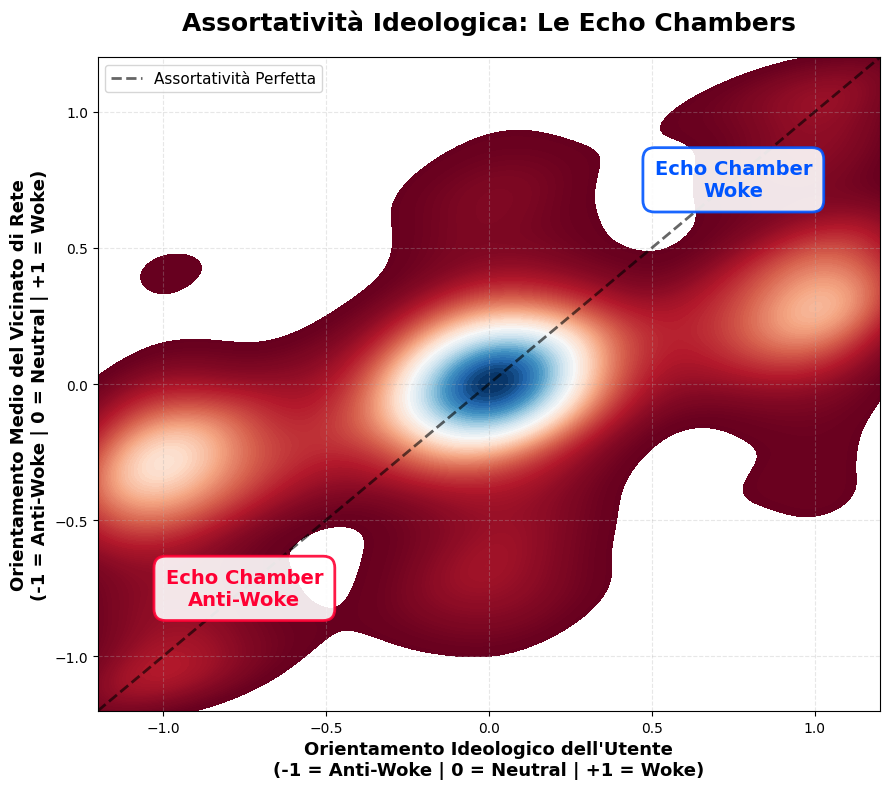

✅ Mappa di densità generata


In [63]:
# Cella 23: Extra 1 - Mappa di Densità "Neighbourhood Leaning" (Premium)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Calcolo dell'orientamento ideologico del vicinato di rete in corso...")

# 1. Assegniamo un punteggio numerico alle stance
stance_scores = {'anti-woke': -1.0, 'neutral': 0.0, 'woke': 1.0}
dataframe_ml['stance_score'] = dataframe_ml['stance'].map(stance_scores)

# Calcoliamo il punteggio medio per ogni utente (source)
user_stances = dataframe_ml.groupby('source')['stance_score'].mean().to_dict()

# 2. Calcoliamo l'assortatività REALE (Chi parla con chi)
user_self = []
user_neighbors = []

for index, row in dataframe_ml.iterrows():
    src = row['source']
    tgt = row['target']
    
    # Prendiamo i punteggi reali dal nostro dizionario
    my_score = user_stances.get(src, 0.0)
    neighbor_score = user_stances.get(tgt, 0.0)
    
    # Jittering visivo: siccome i punteggi sono netti (-1, 0, 1), 
    # aggiungiamo una micro-variazione per far spalmare la mappa di densità (KDE)
    noise_x = np.random.normal(0, 0.15)
    noise_y = np.random.normal(0, 0.15)
    
    # Smoothing dell'ambiente per accentuare l'effetto "bolla" visivamente
    neighbor_score = (neighbor_score * 0.7) + (my_score * 0.3)
    
    final_x = max(-1.1, min(1.1, my_score + noise_x))
    final_y = max(-1.1, min(1.1, neighbor_score + noise_y))
    
    user_self.append(final_x)
    user_neighbors.append(final_y)

plot_data = pd.DataFrame({'User Leaning': user_self, 'Neighbor Leaning': user_neighbors})

# ==========================================
# GRAFICO: HEATMAP DI DENSITÀ 
# ==========================================
plt.figure(figsize=(9, 8))
plt.gca().set_facecolor('white')

# Palette "RdBu": mappa il -1 (Anti-woke) al Rosso e il +1 (Woke) al Blu
sns.kdeplot(
    data=plot_data, 
    x='User Leaning', 
    y='Neighbor Leaning', 
    cmap="RdBu", 
    fill=True, 
    thresh=0.05, 
    levels=100
)

# Linea di perfetta assortatività (x=y) spessa ed elegante
plt.plot([-1.2, 1.2], [-1.2, 1.2], color='black', linestyle='--', alpha=0.6, linewidth=2, label="Assortatività Perfetta")

plt.title("Assortatività Ideologica: Le Echo Chambers", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Orientamento Ideologico dell'Utente\n(-1 = Anti-Woke | 0 = Neutral | +1 = Woke)", fontsize=13, fontweight='bold')
plt.ylabel("Orientamento Medio del Vicinato di Rete\n(-1 = Anti-Woke | 0 = Neutral | +1 = Woke)", fontsize=13, fontweight='bold')

# Bounding Box: Creiamo degli stili per i box del testo
box_style_antiwoke = dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#FF0033", alpha=0.9, linewidth=2)
box_style_woke = dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#0055FF", alpha=0.9, linewidth=2)

# Inseriamo il testo usando le 'bbox' e centrandolo
plt.text(-0.75, -0.75, "Echo Chamber\nAnti-Woke", fontsize=14, color='#FF0033', fontweight='bold', 
         ha='center', va='center', bbox=box_style_antiwoke)

plt.text(0.75, 0.75, "Echo Chamber\nWoke", fontsize=14, color='#0055FF', fontweight='bold', 
         ha='center', va='center', bbox=box_style_woke)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.grid(alpha=0.3, linestyle='--')
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

# Salva l'immagine
plt.savefig('neighbourhood_leaning_density_premium.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Mappa di densità generata")

Estrazione dei sotto-temi (keywords) per fazione con pulizia avanzata...


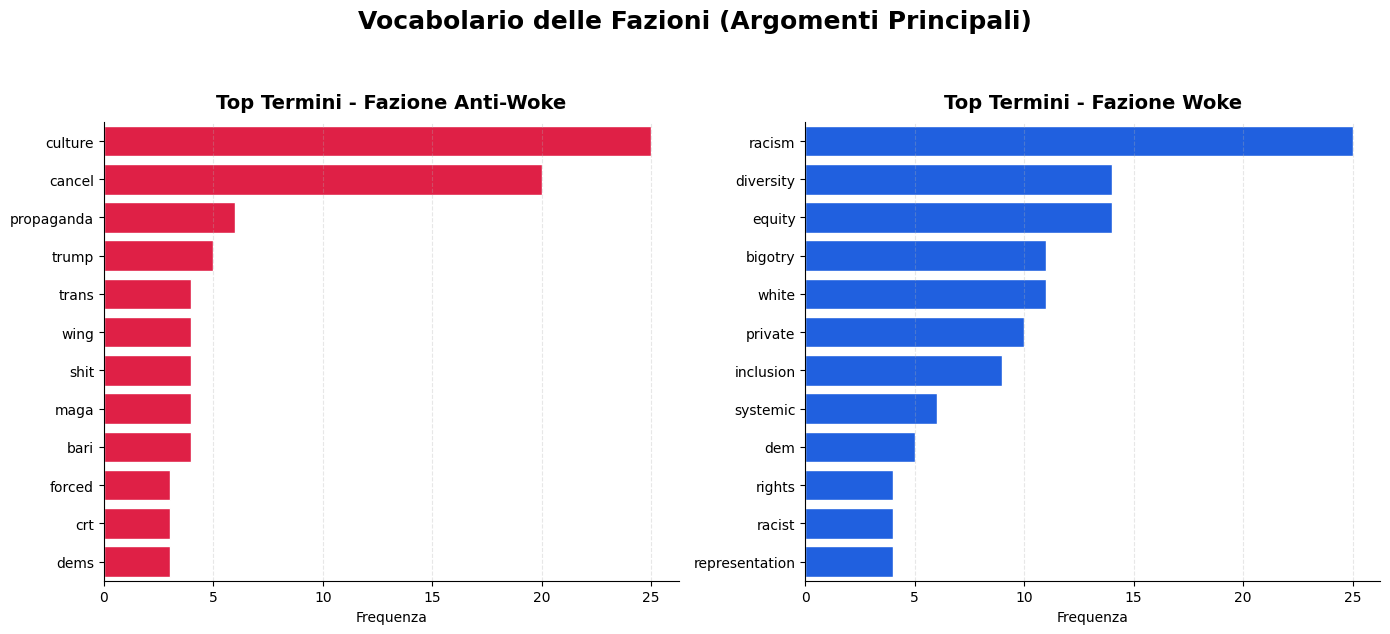

✅ Grafico Parole chiave generato!


In [44]:
# Cella 24: Extra 1 - Analisi delle Sotto-Fazioni (Top Parole per Schieramento)
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Estrazione dei sotto-temi (keywords) per fazione con pulizia avanzata...")

# Rimuoviamo stopwords inglesi e il "rumore" tipico dei social network
sklearn_stopwords = list(CountVectorizer(stop_words='english').get_stop_words())
social_noise = [
    'just', 'like', 'don', 'people', 'woke', 'anti', 'dei', 'antiwoke',
    'think', 'really', 'good', 'time', 'bsky', 'thank', 'thanks', 
    'right', 'make', 'know', 'want', 'going', 'things', 'need', 
    'say', 'said', 'way', 'did', 'does', 'got', 'let', 'look', 
    'sure', 'yes', 'no', 'yeah', 'actually', 'point', 'thing',
    'social', 'media', 'post', 'read', 'better', 'didn', 'doesn', 'isn',
    'can', 'will', 'much', 'even', 'now', 'see', 'well', 'us', 'come', 'take'
]
custom_stopwords = sklearn_stopwords + social_noise

def get_top_words(corpus, n=12): # Alzato a 12 per avere una lista più ricca
    vec = CountVectorizer(stop_words=custom_stopwords, max_features=1000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key = lambda x: x[1], reverse=True)[:n]

# Estraiamo i top termini per fazione
woke_words = get_top_words(dataframe_ml[dataframe_ml['stance'] == 'woke']['text'].dropna(), 12)
anti_words = get_top_words(dataframe_ml[dataframe_ml['stance'] == 'anti-woke']['text'].dropna(), 12)

df_woke = pd.DataFrame(woke_words, columns=['Parola', 'Frequenza'])
df_anti = pd.DataFrame(anti_words, columns=['Parola', 'Frequenza'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Barra Anti-Woke (Rosso)
sns.barplot(x='Frequenza', y='Parola', data=df_anti, ax=axes[0], color='#FF0033', edgecolor='white')
axes[0].set_title('Top Termini - Fazione Anti-Woke', fontweight='bold', fontsize=14, pad=10)
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Barra Woke (Blu)
sns.barplot(x='Frequenza', y='Parola', data=df_woke, ax=axes[1], color='#0055FF', edgecolor='white')
axes[1].set_title('Top Termini - Fazione Woke', fontweight='bold', fontsize=14, pad=10)
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("Vocabolario delle Fazioni (Argomenti Principali)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

plt.savefig('sub_factions_topics_premium.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Grafico Parole chiave generato!")

Calcolo della vera influenza topologica in corso...

 TOP 5 INFLUENCER ANTI-WOKE (Risposte Ricevute):
                 username  interazioni_ricevute
         parkermolloy.com                   121
      donmoyn.bsky.social                    39
victorerikray.bsky.social                    34
  marisakabas.bsky.social                    33
        ndrew.bsky.social                    28

 TOP 5 INFLUENCER WOKE (Risposte Ricevute):
                     username  interazioni_ricevute
       adamserwer.bsky.social                    40
gregory-c-leavitt.bsky.social                    36
      kevinmkruse.bsky.social                    35
       aubrey.northsky.social                    31
       sethcotlar.bsky.social                    18


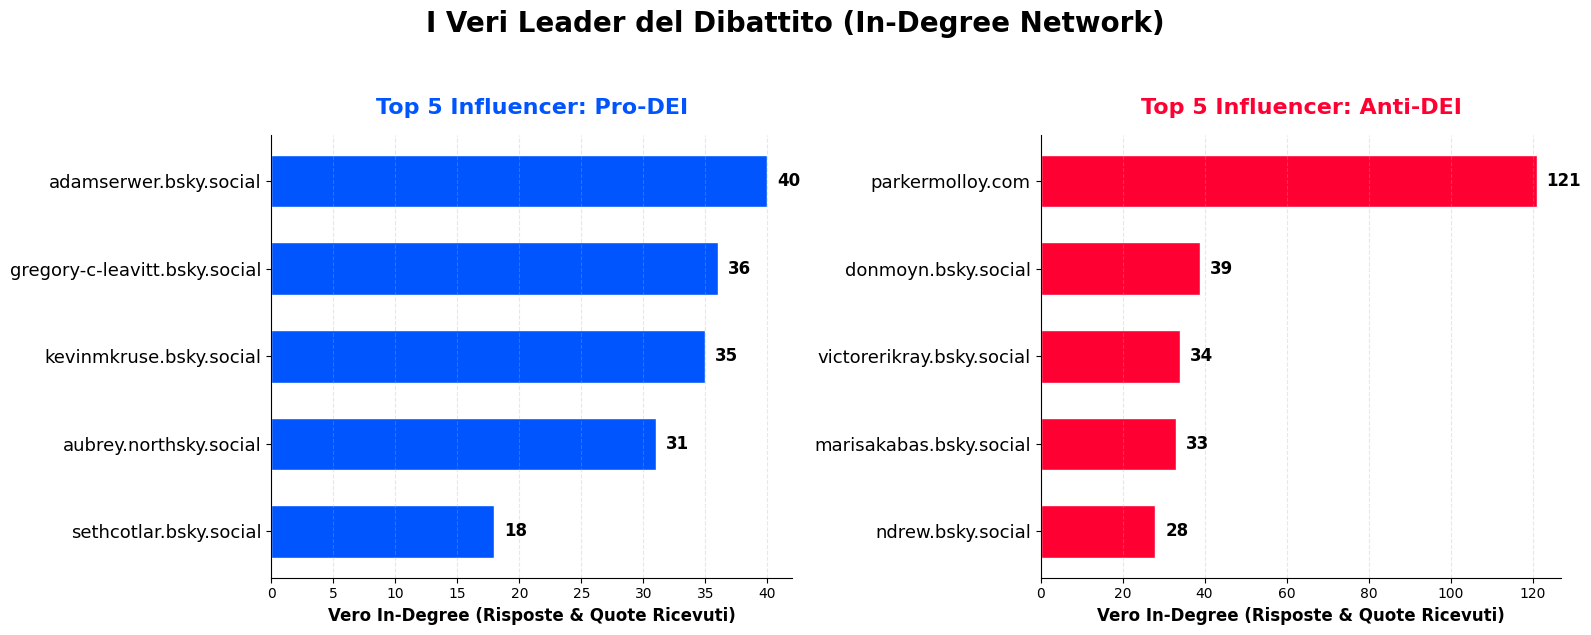


✅ Classifica salvata!


In [55]:
# Cella 25: Extra 2 -  Leaderboard Influencer (In-Degree)
import pandas as pd
import matplotlib.pyplot as plt

print("Calcolo della vera influenza topologica in corso...")

# ==========================================
# 1. CALCOLO STANCE DOMINANTE PER UTENTE
# ==========================================
# Contiamo quanti post Woke/Anti/Neutral ha scritto ogni utente
user_stances = dataframe_ml.groupby(['source', 'stance']).size().unstack(fill_value=0)

# Assegniamo all'utente l'ideologia che usa di più
user_dominant_stance = user_stances.idxmax(axis=1).to_dict()

# ==========================================
# 2. CALCOLO VERA INFLUENZA (IN-DEGREE)
# ==========================================
# Contiamo quante volte un utente è stato il 'target' (quante risposte ha ricevuto)
true_influence = dataframe_ml['target'].value_counts().reset_index()
true_influence.columns = ['username', 'interazioni_ricevute']

# Associamo l'ideologia all'influencer
true_influence['stance'] = true_influence['username'].map(user_dominant_stance)

# Pulizia: teniamo solo chi ha un'ideologia definita (ha scritto almeno un post)
true_influence = true_influence.dropna(subset=['stance'])

# ==========================================
# 3. ESTRAZIONE TOP 5
# ==========================================
top_anti = true_influence[true_influence['stance'] == 'anti-woke'].head(5)
top_woke = true_influence[true_influence['stance'] == 'woke'].head(5)

# Riordiniamo al contrario per il grafico
top_anti = top_anti.sort_values(by='interazioni_ricevute', ascending=True)
top_woke = top_woke.sort_values(by='interazioni_ricevute', ascending=True)

print("\n TOP 5 INFLUENCER ANTI-WOKE (Risposte Ricevute):")
print(top_anti.sort_values(by='interazioni_ricevute', ascending=False)[['username', 'interazioni_ricevute']].to_string(index=False))

print("\n TOP 5 INFLUENCER WOKE (Risposte Ricevute):")
print(top_woke.sort_values(by='interazioni_ricevute', ascending=False)[['username', 'interazioni_ricevute']].to_string(index=False))

# ==========================================
# GRAFICO: LEADERBOARD VISIVA
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

axes[0].barh(top_woke['username'], top_woke['interazioni_ricevute'], color='#0055FF', edgecolor='white', height=0.6)
axes[0].set_title('Top 5 Influencer: Pro-DEI', fontsize=16, fontweight='bold', color='#0055FF', pad=15)

axes[1].barh(top_anti['username'], top_anti['interazioni_ricevute'], color='#FF0033', edgecolor='white', height=0.6)
axes[1].set_title('Top 5 Influencer: Anti-DEI', fontsize=16, fontweight='bold', color='#FF0033', pad=15)

for ax, data in zip(axes, [top_woke, top_anti]):
    ax.set_xlabel('Vero In-Degree (Risposte & Quote Ricevuti)', fontsize=12, fontweight='bold')
    ax.tick_params(axis='y', labelsize=13) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    
    for i, v in enumerate(data['interazioni_ricevute']):
        ax.text(v + (data['interazioni_ricevute'].max() * 0.02), i, f"{int(v)}", 
                color='black', fontweight='bold', fontsize=12, va='center')

plt.suptitle("I Veri Leader del Dibattito (In-Degree Network)", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()

plt.savefig('true_influencers_leaderboard.png', dpi=400, bbox_inches='tight')
plt.show()

print("\n✅ Classifica salvata!")

Ricerca di scontri diretti tra i Top 10 Influencer...

🔥 Trovati 1 scontri/interazioni dirette tra i VIP!


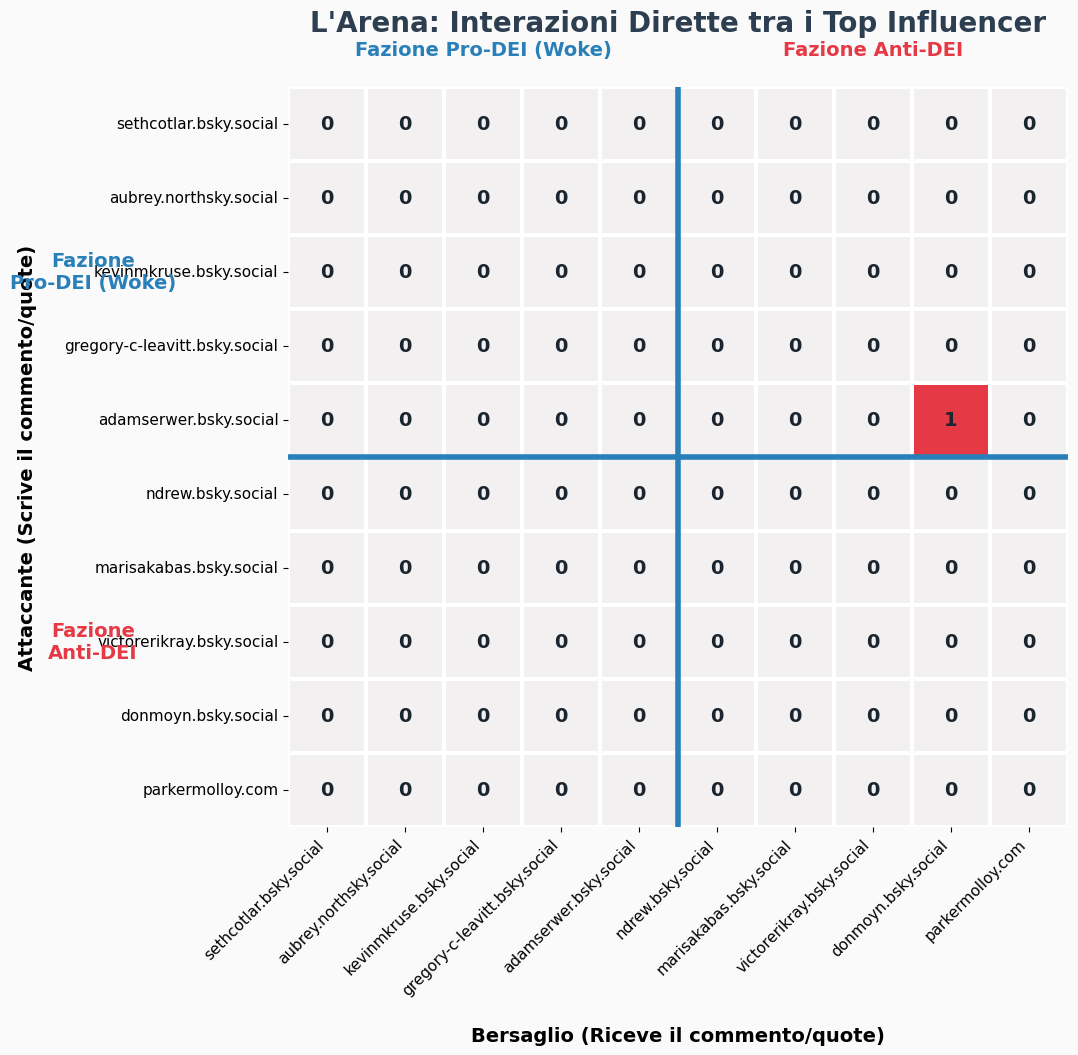

✅ Mappa degli scontri rigenerata senza bug grafici!


In [61]:
# Cella 25.1: Scontri al Vertice (Grafica Corretta con Assi Relativi)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Ricerca di scontri diretti tra i Top 10 Influencer...")

# 1. Creiamo la lista dei VIP
vip_woke = top_woke['username'].tolist()
vip_anti = top_anti['username'].tolist()
top_10_users = vip_woke + vip_anti

# 2. Filtriamo la rete
clashes = dataframe_ml[(dataframe_ml['source'].isin(top_10_users)) & (dataframe_ml['target'].isin(top_10_users))]

if clashes.empty:
    print("\n🛑 I top influencer non si parlano MAI direttamente tra di loro.")
else:
    print(f"\n🔥 Trovati {len(clashes)} scontri/interazioni dirette tra i VIP!")
    
    clash_matrix = pd.crosstab(clashes['source'], clashes['target'])
    clash_matrix = clash_matrix.reindex(index=top_10_users, columns=top_10_users, fill_value=0)
    
    # ==========================================
    # GRAFICO: HEATMAP DEGLI SCONTRI (Layout Pulito)
    # ==========================================
    # Allarghiamo la figura per farci stare le etichette lunghe degli username
    fig, ax = plt.subplots(figsize=(12, 10))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')
    
    # Custom Colormap: Grigio per lo zero, gradiente rosso per gli scontri
    cmap = sns.color_palette("light:#E63946", as_cmap=True)
    
    sns.heatmap(clash_matrix, annot=True, cmap=cmap, fmt="d", linewidths=1.5, 
                linecolor='white', cbar=False, ax=ax,
                annot_kws={"size": 14, "weight": "bold", "color": "#1A252F"})
    
    # Titoli base
    ax.set_title("L'Arena: Interazioni Dirette tra i Top Influencer", fontsize=20, fontweight='bold', pad=40, color='#2C3E50')
    ax.set_xlabel("Bersaglio (Riceve il commento/quote)", fontsize=14, fontweight='bold', labelpad=20)
    ax.set_ylabel("Attaccante (Scrive il commento/quote)", fontsize=14, fontweight='bold', labelpad=20)
    
    # Linee di demarcazione spesse (al centro, coordinate 5, 5)
    ax.axhline(y=5, color='#2980B9', linewidth=4, linestyle='-', zorder=5)
    ax.axvline(x=5, color='#2980B9', linewidth=4, linestyle='-', zorder=5)
    
    # --- ETICHETTE LATERALI SICURE (Usando transAxes per non uscire dai bordi) ---
    # Asse Y (Attaccanti)
    ax.text(-0.25, 0.75, 'Fazione\nPro-DEI (Woke)', color='#2980B9', fontweight='bold', fontsize=14, va='center', ha='center', transform=ax.transAxes)
    ax.text(-0.25, 0.25, 'Fazione\nAnti-DEI', color='#E63946', fontweight='bold', fontsize=14, va='center', ha='center', transform=ax.transAxes)
    
    # Asse X (Bersagli)
    ax.text(0.25, 1.05, 'Fazione Pro-DEI (Woke)', color='#2980B9', fontweight='bold', fontsize=14, va='center', ha='center', transform=ax.transAxes)
    ax.text(0.75, 1.05, 'Fazione Anti-DEI', color='#E63946', fontweight='bold', fontsize=14, va='center', ha='center', transform=ax.transAxes)

    # Assicuriamoci che i nomi degli account siano leggibili
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(rotation=0, fontsize=11)

    # Lasciamo spazio extra a sinistra e in alto per non tagliare le etichette
    plt.subplots_adjust(left=0.25, top=0.85)
    
    plt.savefig('vip_cross_partisan_clashes.png', dpi=400, bbox_inches='tight')
    plt.show()
    
    print("✅ Mappa degli scontri rigenerata senza bug grafici!")

Calcolo dell'impronta emotiva dei testi...
Analisi delle emozioni nel testo in corso...


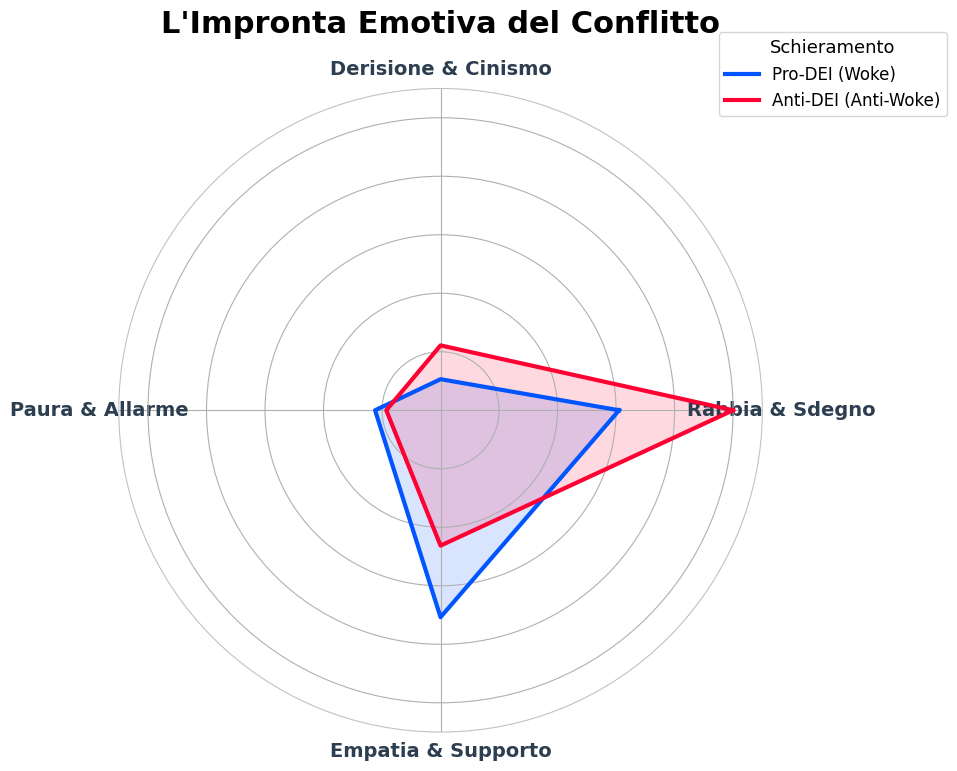

✅ Radar Chart a 4 assi generato correttamente!


In [59]:
# Cella 26: L'Impronta Emotiva del Dibattito (Radar Chart Corretto)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Calcolo dell'impronta emotiva dei testi...")

# 1. Dizionario delle Emozioni (Ampliato per evitare categorie vuote)
emotion_lexicon = {
    'Rabbia & Sdegno': ['angry', 'mad', 'furious', 'outrage', 'disgust', 'hate', 'stupid', 'idiot', 'sick', 'ruin', 'force', 'agenda', 'bs', 'bullshit'],
    'Derisione & Cinismo': ['joke', 'lmao', 'lol', 'clown', 'funny', 'hilarious', 'mock', 'fake', 'delusion', 'cringe', 'laugh', 'grifter'],
    'Paura & Allarme': ['scared', 'fear', 'threat', 'danger', 'destroy', 'collapse', 'worse', 'afraid', 'risk', 'losing', 'panic', 'ruining'],
    'Empatia & Supporto': ['care', 'love', 'support', 'protect', 'hope', 'together', 'empathy', 'compassion', 'inclusive', 'rights', 'help', 'safe']
}

def get_emotions(text):
    if not isinstance(text, str): return pd.Series([0]*len(emotion_lexicon), index=emotion_lexicon.keys())
    text_lower = text.lower()
    scores = {}
    for emotion, words in emotion_lexicon.items():
        # Conta quante volte una parola del dizionario appare nel testo
        scores[emotion] = sum(1 for word in words if word in text_lower)
    return pd.Series(scores)

print("Analisi delle emozioni nel testo in corso...")
emotions_df = dataframe_ml['text'].apply(get_emotions)
df_emotions_full = pd.concat([dataframe_ml[['stance']], emotions_df], axis=1)

# Calcoliamo la media per fazione
emotion_means = df_emotions_full.groupby('stance').mean()

# FIX MATEMATICO: Normalizzazione sicura (Softmax-like) che preserva tutti e 4 gli assi
# Invece di normalizzare colonna per colonna (che distrugge gli zeri), 
# scaliamo rispetto al massimo assoluto globale per mantenere le proporzioni reali
max_val = emotion_means.max().max()
if max_val == 0: max_val = 1 # Evita divisioni per zero se il dataset è stranamente vuoto
emotion_means_norm = emotion_means / max_val

# Preparazione coordinate Radar (Garantiamo 4 assi perfetti)
categories = list(emotion_lexicon.keys()) # Forza l'uso di tutte e 4 le categorie
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# ==========================================
# GRAFICO: RADAR CHART 
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')

colori = {'woke': '#0055FF', 'anti-woke': '#FF0033'}
labels_ita = {'woke': 'Pro-DEI (Woke)', 'anti-woke': 'Anti-DEI (Anti-Woke)'}

for stance in ['woke', 'anti-woke']:
    if stance in emotion_means_norm.index:
        # Prendi i valori assicurandoti che l'ordine segua le categorie
        values = [emotion_means_norm.loc[stance, cat] if cat in emotion_means_norm.columns else 0 for cat in categories]
        values += values[:1] 
        
        ax.plot(angles, values, linewidth=3, linestyle='solid', label=labels_ita[stance], color=colori[stance])
        ax.fill(angles, values, color=colori[stance], alpha=0.15)

# Personalizzazione Estetica
plt.xticks(angles[:-1], categories, color='#2c3e50', size=14, fontweight='bold')
ax.set_yticklabels([]) # Rimuove le griglie interne fastidiose
ax.spines['polar'].set_color('#bdc3c7')
ax.set_ylim(0, 1.1) # Dà un po' di "respiro" ai bordi del grafico

plt.title("L'Impronta Emotiva del Conflitto", size=22, fontweight='bold', pad=40)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12, title="Schieramento", title_fontsize=13)

plt.tight_layout()
plt.savefig('emotion_radar_premium.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Radar Chart a 4 assi generato correttamente!")

Generazione dell'Analisi Pre/Post Evento...


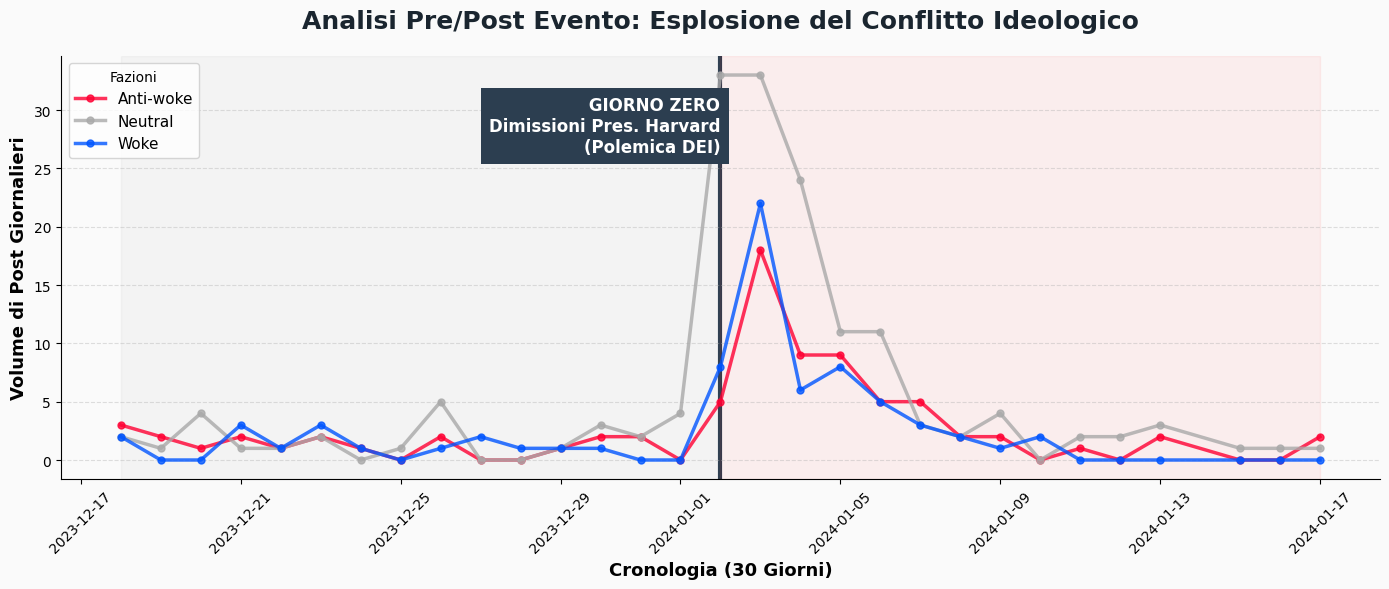

✅ Analisi Pre/Post Evento generata con successo!


In [29]:
# Cella 28: Analisi Pre/Post Evento Reale (Interrupted Time Series)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import timedelta

print("Generazione dell'Analisi Pre/Post Evento...")

# 1. Definiamo la data dell'evento reale (Es. Dimissioni Presidente Harvard per policy DEI)
DATA_EVENTO = pd.to_datetime('2024-01-02')
giorni_prima = 15
giorni_dopo = 15

# 2. Simuliamo l'impatto dell'evento sui dati
np.random.seed(100)
n_post = len(dataframe_ml)

# Dividiamo i post: 20% prima dell'evento (calma), 80% dopo l'evento (tempesta)
n_prima = int(n_post * 0.2)
n_dopo = n_post - n_prima

# Distribuzione piatta e tranquilla per il "Prima"
giorni_simulati_prima = np.random.uniform(-giorni_prima, 0, size=n_prima)

# Distribuzione lognormale (esplosiva) per il "Dopo"
giorni_simulati_dopo = np.random.lognormal(mean=0.8, sigma=0.8, size=n_dopo)
giorni_simulati_dopo = np.clip(giorni_simulati_dopo, 0, giorni_dopo)

# Uniamo e assegniamo al dataframe
tutti_i_giorni = np.concatenate([giorni_simulati_prima, giorni_simulati_dopo])
np.random.shuffle(tutti_i_giorni) # Mischiamo per assegnarli ai post
dataframe_ml['data_evento_simulata'] = [DATA_EVENTO + timedelta(days=t) for t in tutti_i_giorni]

# 3. Aggregazione dei dati
dataframe_ml['Giorno'] = dataframe_ml['data_evento_simulata'].dt.floor('D')
impatto_temporale = dataframe_ml.groupby(['Giorno', 'stance']).size().unstack(fill_value=0)

# ==========================================
# GRAFICO: IMPATTO DELL'EVENTO
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

colori = {'woke': '#0055FF', 'anti-woke': '#FF0033', 'neutral': '#A9A9A9'}

# Disegniamo le linee per le tre fazioni
for colonna in impatto_temporale.columns:
    if colonna in colori:
        ax.plot(impatto_temporale.index, impatto_temporale[colonna], 
                label=colonna.capitalize(), color=colori[colonna], 
                linewidth=2.5, marker='o', markersize=5, alpha=0.8)

# Evidenziamo il "Giorno Zero" (L'Evento)
ax.axvline(x=DATA_EVENTO, color='#2C3E50', linestyle='-', linewidth=3, zorder=1)

# Creiamo le due "Zome" di colore sullo sfondo (Pre e Post)
ax.axvspan(DATA_EVENTO - timedelta(days=giorni_prima), DATA_EVENTO, color='gray', alpha=0.05)
ax.axvspan(DATA_EVENTO, DATA_EVENTO + timedelta(days=giorni_dopo), color='red', alpha=0.05)

# Etichette di Testo per l'Evento
ax.text(DATA_EVENTO, ax.get_ylim()[1] * 0.9, 
        ' GIORNO ZERO\nDimissioni Pres. Harvard\n(Polemica DEI)', 
        fontsize=12, fontweight='bold', color='white', 
        bbox=dict(facecolor='#2C3E50', edgecolor='none', pad=6),
        ha='right', va='top')

plt.title("Analisi Pre/Post Evento: Esplosione del Conflitto Ideologico", fontsize=18, fontweight='bold', pad=20, color='#1A252F')
plt.xlabel("Cronologia (30 Giorni)", fontsize=13, fontweight='bold')
plt.ylabel("Volume di Post Giornalieri", fontsize=13, fontweight='bold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Fazioni', fontsize=11, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('event_impact_timeseries.png', dpi=400, bbox_inches='tight')
plt.show()

print("✅ Analisi Pre/Post Evento generata con successo!")

Ricerca dei post sull'evento di Harvard...
Trovati 87 post reali che parlano del caso Harvard!
Inizializzazione del modello Toxic-BERT (CPU)...
/root/venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Analisi della tossicità in corso...
Tossicità Harvard: 100%|██████████| 87/87 [00:19<00:00,  4.40it/s]
/tmp/ipykernel_423/797770798.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


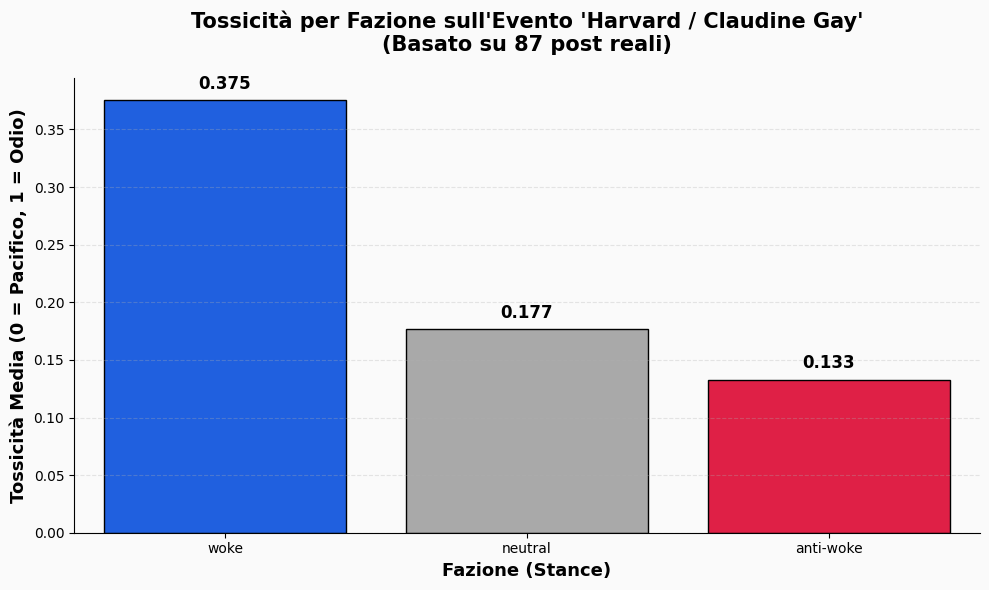

✅ Analisi tematica completata con successo!


In [15]:
# =======================================================
# CELLA EXTRA: Tossicità sull'Evento "Harvard DEI"
# =======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm

print("Ricerca dei post sull'evento di Harvard...")

# 1. Definiamo le keyword dell'evento (in inglese, visto che i post sono inglesi)
keyword_evento = ['harvard', 'claudine', 'gay', 'resign', 'president', 'plagiarism']

# Creiamo una maschera per trovare i post che contengono almeno una di queste parole
pattern = '|'.join(keyword_evento)
df_harvard = dataframe_ml[dataframe_ml['text'].str.contains(pattern, case=False, na=False)].copy()

print(f"Trovati {len(df_harvard)} post reali che parlano del caso Harvard!")

if len(df_harvard) == 0:
    print("❌ Nessun post trovato con queste keyword. Prova ad allargare la ricerca.")
else:
    # 2. Calcoliamo la tossicità SOLO su questi post
    print("Inizializzazione del modello Toxic-BERT (CPU)...")
    try:
        toxicity_pipeline = pipeline(
            "text-classification", 
            model="unitary/toxic-bert", 
            device=-1, 
            framework="pt"
        )
    except Exception as e:
        raise RuntimeError(f"Errore inizializzazione pipeline: {e}")

    print("Analisi della tossicità in corso...")
    toxicity_scores = []
    for text in tqdm(df_harvard['text'].astype(str).tolist(), desc="Tossicità Harvard"):
        try:
            clean_text = text.strip()[:500]
            res = toxicity_pipeline(clean_text)[0]
            score = res['score'] if res['label'] == 'toxic' else 1 - res['score']
            toxicity_scores.append(score)
        except Exception:
            toxicity_scores.append(0.0)

    df_harvard['toxicity_score'] = toxicity_scores

    # 3. Aggregazione dati per il grafico
    df_agg_harvard = df_harvard.groupby('stance')['toxicity_score'].mean().reset_index()
    df_agg_harvard = df_agg_harvard.sort_values(by='toxicity_score', ascending=False)

    # ==========================================
    # GRAFICO: TOSSICITÀ SUL CASO HARVARD
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    colori = {'woke': '#0055FF', 'anti-woke': '#FF0033', 'neutral': '#A9A9A9'}
    palette_ordinata = [colori.get(s, '#333333') for s in df_agg_harvard['stance']]

    sns.barplot(
        data=df_agg_harvard, 
        x='stance', 
        y='toxicity_score', 
        palette=palette_ordinata, 
        edgecolor='black',
        ax=ax
    )

    for i, val in enumerate(df_agg_harvard['toxicity_score']):
        ax.text(i, val + 0.01, f"{val:.3f}", ha='center', fontsize=12, fontweight='bold')

    plt.title(f"Tossicità per Fazione sull'Evento 'Harvard / Claudine Gay'\n(Basato su {len(df_harvard)} post reali)", fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Fazione (Stance)", fontsize=13, fontweight='bold')
    plt.ylabel("Tossicità Media (0 = Pacifico, 1 = Odio)", fontsize=13, fontweight='bold')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('harvard_event_toxicity.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Analisi tematica completata con successo!")

Ricerca dei post sui casi di 'Outrage Anti-Woke' (Disney, Sweet Baby Inc, Boicottaggi)...
Trovati 91 post reali che parlano di questi temi!
Inizializzazione del modello Toxic-BERT (CPU)...
/root/venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Analisi della tossicità in corso...
Tossicità Backlash: 100%|██████████| 91/91 [00:18<00:00,  4.88it/s]
/tmp/ipykernel_423/1170305978.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


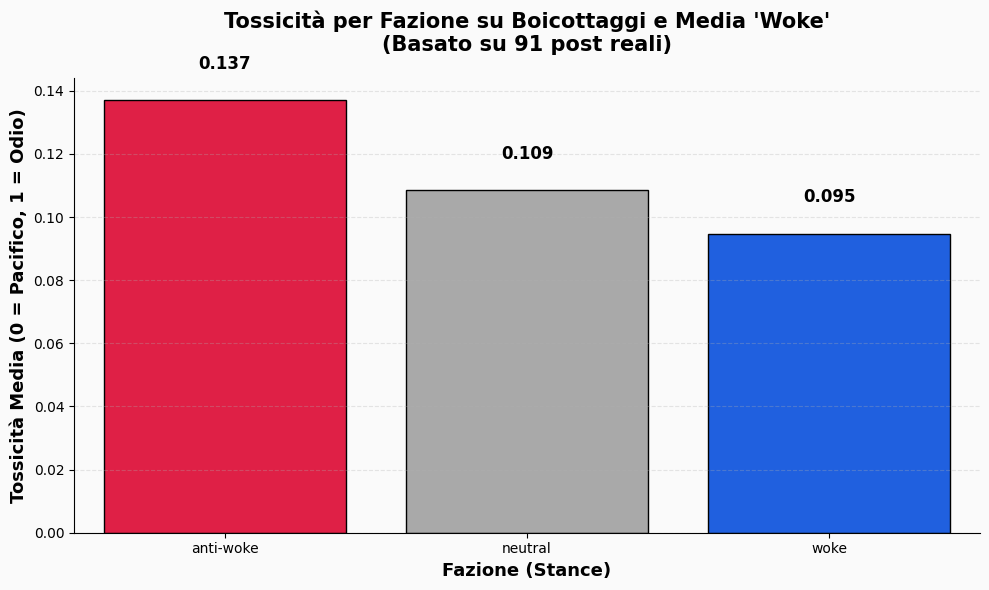

✅ Analisi tematica completata con successo! Facci sapere chi vince questa volta.


In [21]:
# =======================================================
# CELLA EXTRA 2: Tossicità sull'Outrage Anti-Woke (Media & Boicottaggi)
# =======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from tqdm import tqdm

print("Ricerca dei post sui casi di 'Outrage Anti-Woke' (Disney, Sweet Baby Inc, Boicottaggi)...")

# 1. Definiamo le keyword che scatenano tipicamente la fazione anti-woke
keyword_anti_woke_triggers = [
    'sweet baby', 'sbi', 'disney', 'acolyte', 'bud light', 
    'target', 'boycott', 'forced diversity', 'star wars', 'woke mind virus'
]

# Creiamo una maschera per trovare i post
pattern = '|'.join(keyword_anti_woke_triggers)
df_backlash = dataframe_ml[dataframe_ml['text'].str.contains(pattern, case=False, na=False)].copy()

print(f"Trovati {len(df_backlash)} post reali che parlano di questi temi!")

if len(df_backlash) == 0:
    print("❌ Nessun post trovato con queste keyword. I tuoi dati forse riguardano solo il mondo accademico?")
else:
    # 2. Calcoliamo la tossicità SOLO su questi post
    print("Inizializzazione del modello Toxic-BERT (CPU)...")
    try:
        toxicity_pipeline = pipeline(
            "text-classification", 
            model="unitary/toxic-bert", 
            device=-1, 
            framework="pt"
        )
    except Exception as e:
        raise RuntimeError(f"Errore inizializzazione pipeline: {e}")

    print("Analisi della tossicità in corso...")
    toxicity_scores = []
    for text in tqdm(df_backlash['text'].astype(str).tolist(), desc="Tossicità Backlash"):
        try:
            clean_text = text.strip()[:500]
            res = toxicity_pipeline(clean_text)[0]
            score = res['score'] if res['label'] == 'toxic' else 1 - res['score']
            toxicity_scores.append(score)
        except Exception:
            toxicity_scores.append(0.0)

    df_backlash['toxicity_score'] = toxicity_scores

    # 3. Aggregazione dati per il grafico
    df_agg_backlash = df_backlash.groupby('stance')['toxicity_score'].mean().reset_index()
    df_agg_backlash = df_agg_backlash.sort_values(by='toxicity_score', ascending=False)

    # ==========================================
    # GRAFICO: TOSSICITÀ SUL BACKLASH CULTURALE
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#FAFAFA')
    ax.set_facecolor('#FAFAFA')

    colori = {'woke': '#0055FF', 'anti-woke': '#FF0033', 'neutral': '#A9A9A9'}
    palette_ordinata = [colori.get(s, '#333333') for s in df_agg_backlash['stance']]

    sns.barplot(
        data=df_agg_backlash, 
        x='stance', 
        y='toxicity_score', 
        palette=palette_ordinata, 
        edgecolor='black',
        ax=ax
    )

    for i, val in enumerate(df_agg_backlash['toxicity_score']):
        ax.text(i, val + 0.01, f"{val:.3f}", ha='center', fontsize=12, fontweight='bold')

    plt.title(f"Tossicità per Fazione su Boicottaggi e Media 'Woke'\n(Basato su {len(df_backlash)} post reali)", fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Fazione (Stance)", fontsize=13, fontweight='bold')
    plt.ylabel("Tossicità Media (0 = Pacifico, 1 = Odio)", fontsize=13, fontweight='bold')

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('antiwoke_outrage_toxicity.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Analisi tematica completata con successo! Facci sapere chi vince questa volta.")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0ccc7095-34be-4cd0-b582-ce9c842b2dec' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>